# CST8506 Assignment 2: CIFAR-10 Classification

Classifies CIFAR-10 images using MLP (scikit-learn),
Neural Network with Dense layers (Keras), and four CNN
architectures (Keras). Studies the effect of various
hyperparameters on model performance.

In [210]:
# 强制标准输出使用 UTF-8 编码（修复 Windows 重定向时 Keras 表格乱码）
# Force stdout to UTF-8 encoding (fix garbled Keras tables on Windows redirect)
# 注意：Jupyter 的 OutStream 不支持 reconfigure()，需要 try/except
# Note: Jupyter's OutStream doesn't support reconfigure(), use try/except
import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')
except AttributeError:
    pass  # Jupyter notebook 不需要此操作 / Not needed in Jupyter

# 导入操作系统和路径模块
# Import os and path modules
import os
import pickle

# 抑制 TensorFlow 信息输出（避免 PowerShell 误报错误）
# Suppress TensorFlow info messages (avoid PowerShell stderr issues)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
from pathlib import Path

# 导入数值计算和数据处理库
# Import numerical computing and data processing libraries
import numpy as np

# 导入绘图库
# Import plotting library
%matplotlib inline
import matplotlib
# matplotlib.use('Agg')  # notebook 不需要 Agg 后端
import matplotlib.pyplot as plt

# 导入表格格式化工具
# Import table formatting utility
from tabulate import tabulate

# 导入 scikit-learn MLP 分类器
# Import scikit-learn MLP classifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 导入 TensorFlow / Keras 模块
# Import TensorFlow / Keras modules
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# 导入警告模块以抑制收敛警告
# Import warnings module to suppress convergence warnings
import warnings
warnings.filterwarnings('ignore')

## Configuration Constants

In [211]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
# 固定随机种子以确保结果可复现
# Fixed random seed for reproducibility
RANDOM_STATE = 42

# 输出图片目录
# Output images directory
OUTPUT_DIR = Path('assignment2_images')

# 模型缓存目录（训练一次后自动保存，下次运行跳过训练）
# Model cache directory (auto-save after training, skip on re-run)
CACHE_DIR = Path('assignment2_cache')

# 图片分辨率
# Image resolution
IMAGE_DPI = 150

# 分隔线宽度
# Divider line width
LINE_WIDTH = 60

# Keras 训练轮数（为演示目的使用较少轮数）
# Keras training epochs (fewer epochs for demonstration)
EPOCHS = 15

# 批大小
# Batch size
BATCH_SIZE = 64

## Environment Setup

In [212]:
# ============================================================
# 环境设置
# Environment Setup
# ============================================================
# 创建输出目录
# Create output directory
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

# 设置随机种子
# Set random seeds
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("=" * LINE_WIDTH)
print("CST8506 Assignment 2: CIFAR-10 Classification")
print("Author: Peng Wang | Student Number: 041107730")
print("=" * LINE_WIDTH)
print()

CST8506 Assignment 2: CIFAR-10 Classification
Author: Peng Wang | Student Number: 041107730



## Step 1: Data Understanding - Load CIFAR-10 Dataset

In [213]:
# ============================================================
# 步骤 1：数据理解 - 加载 CIFAR-10 数据集
# Step 1: Data Understanding - Load CIFAR-10 Dataset
# ============================================================
print("=" * LINE_WIDTH)
print("Step 1: Data Understanding - Load CIFAR-10 Dataset")
print("=" * LINE_WIDTH)

# 从 Keras 加载 CIFAR-10 数据集
# Load CIFAR-10 dataset from Keras
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

# CIFAR-10 的 10 个类别名称
# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Dataset: CIFAR-10 (Keras built-in)")
print(f"Training set shape: {X_train_raw.shape}")
print(f"Test set shape:     {X_test_raw.shape}")
print(f"Image size:         {X_train_raw.shape[1]}x{X_train_raw.shape[2]}x{X_train_raw.shape[3]}")
print(f"Number of classes:  {len(class_names)}")
print(f"Class names:        {class_names}")
print(f"Pixel value range:  [{X_train_raw.min()}, {X_train_raw.max()}]")
print()

# 类别分布
# Class distribution
print("Class distribution (training set):")
for i, name in enumerate(class_names):
    count = np.sum(y_train_raw == i)
    print(f"  {i}. {name:12s}: {count} images ({count/len(y_train_raw)*100:.1f}%)")
print()

Step 1: Data Understanding - Load CIFAR-10 Dataset
Dataset: CIFAR-10 (Keras built-in)
Training set shape: (50000, 32, 32, 3)
Test set shape:     (10000, 32, 32, 3)
Image size:         32x32x3
Number of classes:  10
Class names:        ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Pixel value range:  [0, 255]

Class distribution (training set):
  0. airplane    : 5000 images (10.0%)
  1. automobile  : 5000 images (10.0%)
  2. bird        : 5000 images (10.0%)
  3. cat         : 5000 images (10.0%)
  4. deer        : 5000 images (10.0%)
  5. dog         : 5000 images (10.0%)
  6. frog        : 5000 images (10.0%)
  7. horse       : 5000 images (10.0%)
  8. ship        : 5000 images (10.0%)
  9. truck       : 5000 images (10.0%)



## Step 2: Data Understanding - Visualize Sample Images

Step 2: Data Understanding - Visualize Sample Images


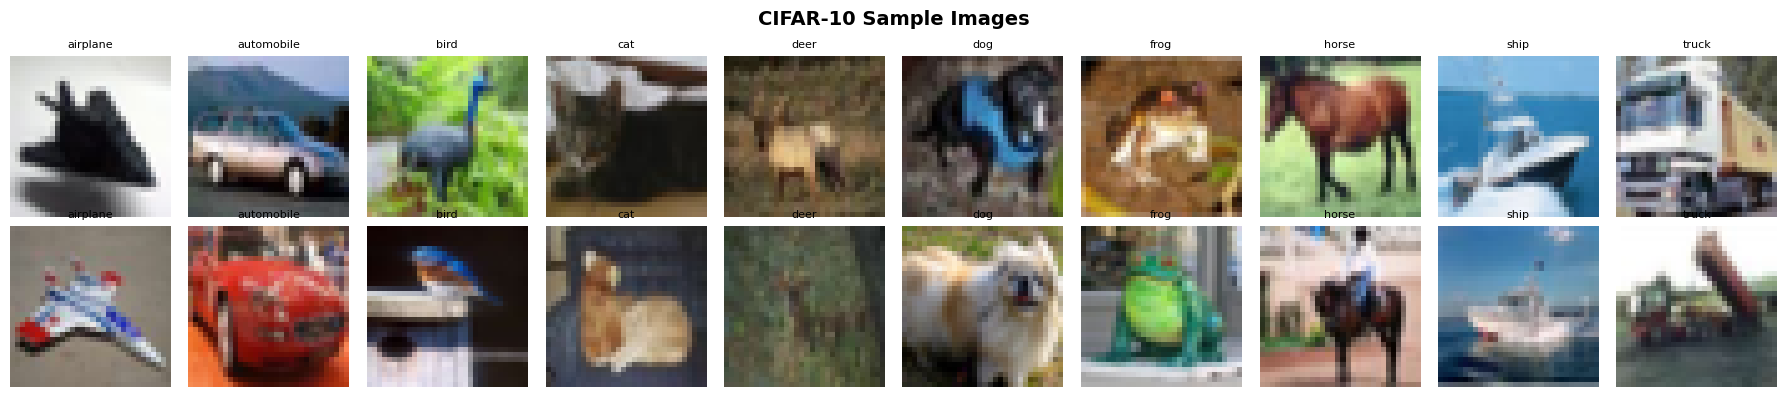

Sample images saved as 'assignment2_images/sample_images.png'



In [214]:
# ============================================================
# 步骤 2：数据理解 - 可视化样本图像
# Step 2: Data Understanding - Visualize Sample Images
# ============================================================
print("=" * LINE_WIDTH)
print("Step 2: Data Understanding - Visualize Sample Images")
print("=" * LINE_WIDTH)

# 为每个类别显示 2 张样本图片
# Show 2 sample images for each class
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for cls in range(10):
    indices = np.where(y_train_raw.flatten() == cls)[0][:2]
    for row, idx in enumerate(indices):
        axes[row, cls].imshow(X_train_raw[idx])
        axes[row, cls].set_title(class_names[cls], fontsize=8)
        axes[row, cls].axis('off')

plt.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Sample images saved as 'assignment2_images/sample_images.png'")
print()

## Step 3: Data Preparation - Normalize and Encode Labels

In [215]:
# ============================================================
# 步骤 3：数据准备 - 归一化和标签编码
# Step 3: Data Preparation - Normalize and Encode Labels
# ============================================================
print("=" * LINE_WIDTH)
print("Step 3: Data Preparation - Normalize and Encode Labels")
print("=" * LINE_WIDTH)

# 将像素值归一化到 [0, 1] 范围
# Normalize pixel values to [0, 1] range
# 原因：神经网络在小数值输入时训练更稳定、更快收敛
# Reason: Neural networks train more stably and converge faster with small input values
X_train_norm = X_train_raw.astype('float32') / 255.0
X_test_norm = X_test_raw.astype('float32') / 255.0

print(f"Normalized pixel range: [{X_train_norm.min()}, {X_train_norm.max()}]")
print(f"X_train shape: {X_train_norm.shape}")
print(f"X_test shape:  {X_test_norm.shape}")

# 将标签展平为一维数组（sklearn MLP 需要）
# Flatten labels to 1D array (needed by sklearn MLP)
y_train_flat = y_train_raw.flatten()
y_test_flat = y_test_raw.flatten()

# 对标签进行 One-Hot 编码（Keras 模型需要）
# One-hot encode labels (needed by Keras models)
y_train_onehot = to_categorical(y_train_flat, 10)
y_test_onehot = to_categorical(y_test_flat, 10)

print(f"y_train_flat shape:   {y_train_flat.shape}")
print(f"y_train_onehot shape: {y_train_onehot.shape}")

# 为 sklearn MLP 将图像展平为一维向量
# Flatten images to 1D vectors for sklearn MLP
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)
print(f"Flattened X_train shape: {X_train_flat.shape}  (32*32*3 = 3072)")
print()

Step 3: Data Preparation - Normalize and Encode Labels
Normalized pixel range: [0.0, 1.0]
X_train shape: (50000, 32, 32, 3)
X_test shape:  (10000, 32, 32, 3)
y_train_flat shape:   (50000,)
y_train_onehot shape: (50000, 10)
Flattened X_train shape: (50000, 3072)  (32*32*3 = 3072)



## Step 4: MLP Classification (scikit-learn)

In [216]:
# ============================================================
# 步骤 4：MLP 分类（scikit-learn）
# Step 4: MLP Classification (scikit-learn)
# ============================================================
print("=" * LINE_WIDTH)
print("Step 4: MLP Classification (scikit-learn MLPClassifier)")
print("=" * LINE_WIDTH)

# ================================================================
# 概念：MLP（多层感知器）
# Concept: MLP (Multi-Layer Perceptron)
# ================================================================
#
# 定义 / Definition:
#   由多层全连接神经元组成的前馈神经网络
#   Feed-forward neural network composed of fully connected layers
#
# 参数说明 / Parameter Explanation:
#   hidden_layer_sizes: 隐藏层结构 / Hidden layer structure
#   activation: 激活函数 / Activation function
#     - relu: f(x) = max(0, x)，稀疏激活，训练快
#     - tanh: f(x) = (e^x - e^-x)/(e^x + e^-x)，输出[-1,1]
#     - logistic: f(x) = 1/(1+e^-x)，输出[0,1]
#   solver: 优化器 / Optimizer
#     - adam: 自适应学习率，最常用
#     - sgd: 随机梯度下降，需手动调学习率
#   batch_size: 每次更新使用的样本数
#   learning_rate_init: 初始学习率
#   max_iter: 最大迭代次数
# ================================================================

# MLP 配置（使用完整训练集，支持缓存）
# MLP configuration (using full training set, with caching)
mlp_cache = CACHE_DIR / 'mlp_model.pkl'

if mlp_cache.exists():
    print("[CACHE] Loading MLP model from cache...")
    with open(mlp_cache, 'rb') as f:
        mlp = pickle.load(f)
else:
    mlp = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        solver='adam',
        batch_size=256,
        learning_rate_init=0.001,
        max_iter=30,
        random_state=RANDOM_STATE,
        verbose=True
    )
    print(f"Training MLP on full dataset: {X_train_flat.shape[0]} samples")
    print("Parameters: hidden=(256,128), activation=relu, solver=adam")
    mlp.fit(X_train_flat, y_train_flat)
    with open(mlp_cache, 'wb') as f:
        pickle.dump(mlp, f)
    print("[CACHE] MLP model saved to cache.")

y_pred_mlp = mlp.predict(X_test_flat)
mlp_acc = accuracy_score(y_test_flat, y_pred_mlp)

print(f"MLP Test Accuracy: {mlp_acc:.4f}")
print()
print("Classification Report (MLP):")
print(classification_report(y_test_flat, y_pred_mlp, target_names=class_names))
print()

Step 4: MLP Classification (scikit-learn MLPClassifier)
[CACHE] Loading MLP model from cache...
MLP Test Accuracy: 0.5153

Classification Report (MLP):
              precision    recall  f1-score   support

    airplane       0.64      0.50      0.56      1000
  automobile       0.62      0.62      0.62      1000
        bird       0.47      0.31      0.37      1000
         cat       0.37      0.35      0.36      1000
        deer       0.47      0.47      0.47      1000
         dog       0.46      0.38      0.41      1000
        frog       0.56      0.56      0.56      1000
       horse       0.47      0.66      0.55      1000
        ship       0.56      0.73      0.64      1000
       truck       0.53      0.58      0.55      1000

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.51     10000
weighted avg       0.52      0.52      0.51     10000




## Helper: Print parameter table with calculations

In [217]:
# ============================================================
# 辅助函数：打印参数计算表格
# Helper: Print parameter table with calculations
# ============================================================
def print_param_table(model, model_name):
    """打印模型参数表格，包含 output shape 和参数数量的计算过程
    Print model parameter table with output shape and param calculations"""
    print(f"\n{'='*LINE_WIDTH}")
    print(f"Parameter Table: {model_name}")
    print(f"{'='*LINE_WIDTH}")

    table_data = []
    for layer in model.layers:
        config = layer.get_config()
        name = layer.name
        output_shape = tuple(layer.output.shape)
        input_shape = tuple(layer.input.shape)
        params = layer.count_params()

        # 生成 output shape 计算说明
        if 'conv2d' in name:
            h, w = input_shape[1], input_shape[2]
            filters = config['filters']
            padding = config['padding']
            if padding == 'same':
                shape_calc = f"same padding: {h}x{w} stays, filters={filters}"
            else:
                ks = config['kernel_size']
                new_h = h - ks[0] + 1
                new_w = w - ks[1] + 1
                shape_calc = f"({h}-{ks[0]}+1)x({w}-{ks[1]}+1)={new_h}x{new_w}, filters={filters}"
        elif 'max_pooling' in name or 'average_pooling' in name:
            h_in, w_in = input_shape[1], input_shape[2]
            pool = config['pool_size']
            h_out, w_out = h_in // pool[0], w_in // pool[1]
            pool_type = "MaxPool" if 'max' in name else "AvgPool"
            shape_calc = f"{pool_type}: {h_in}/{pool[0]}={h_out}, {w_in}/{pool[1]}={w_out}"
        elif 'flatten' in name:
            dims = input_shape[1:]
            product = 1
            for d in dims:
                product *= d
            shape_calc = f"{'x'.join(str(d) for d in dims)} = {product:,}"
        elif 'dense' in name:
            units = config['units']
            shape_calc = f"units={units}"
        elif 'dropout' in name:
            shape_calc = "same as input"
        else:
            shape_calc = str(output_shape)

        # 生成参数数量计算说明
        if 'conv2d' in name:
            ks = config['kernel_size']
            filters = config['filters']
            in_ch = input_shape[-1]
            param_calc = f"({ks[0]}x{ks[1]}x{in_ch}+1)x{filters} = {params:,}"
        elif 'dense' in name:
            in_units = input_shape[-1]
            units = config['units']
            param_calc = f"({in_units}+1)x{units} = {params:,}"
        elif 'max_pooling' in name or 'average_pooling' in name:
            param_calc = "no learnable params"
        elif 'flatten' in name:
            param_calc = "reshape only"
        elif 'dropout' in name:
            param_calc = "no learnable params"
        else:
            param_calc = str(params)

        table_data.append([name, str(output_shape), shape_calc, f"{params:,}", param_calc])

    headers = ['Layer Name', 'Output Shape', 'Shape Calculation', 'Params', 'Param Calculation']
    print(tabulate(table_data, headers=headers, tablefmt='grid'))
    print(f"Total parameters: {model.count_params():,}")
    print()

## Step 5: NN (Dense-only Neural Network)

In [218]:
# ============================================================
# 步骤 5：NN（全连接神经网络，仅 Dense 层）
# Step 5: NN (Dense-only Neural Network)
# ============================================================
print("=" * LINE_WIDTH)
print("Step 5: NN with Dense Layers Only (Keras)")
print("=" * LINE_WIDTH)

# ================================================================
# 概念：全连接神经网络
# Concept: Fully Connected Neural Network
# ================================================================
#
# Dense 层参数说明 / Dense Layer Parameters:
#   units: 神经元数量 / Number of neurons
#   activation: 激活函数 / Activation function
#
# Compile 参数说明 / Compile Parameters:
#   optimizer: 优化器，控制权重更新方式
#     - adam: 自适应矩估计，自动调整学习率
#   loss: 损失函数，衡量预测与真实之间的差距
#     - categorical_crossentropy: 用于多分类 one-hot 标签
#   metrics: 评估指标
#
# Fit 参数说明 / Fit Parameters:
#   epochs: 训练轮数，数据集被遍历的次数
#   batch_size: 每次梯度更新使用的样本数
#   validation_split: 从训练集中划分出的验证比例
# ================================================================

# 构建全连接神经网络
# Build fully connected neural network
nn_model = models.Sequential([
    # Flatten 将 32x32x3 图像展平为 3072 维向量
    # Flatten converts 32x32x3 image to 3072-D vector
    layers.Flatten(input_shape=(32, 32, 3)),

    # 第一个隐藏层：512 个神经元，ReLU 激活
    # First hidden layer: 512 neurons, ReLU activation
    layers.Dense(512, activation='relu'),

    # Dropout 防止过拟合，随机关闭 30% 的神经元
    # Dropout prevents overfitting by randomly disabling 30% of neurons
    layers.Dropout(0.3),

    # 第二个隐藏层：256 个神经元，ReLU 激活
    # Second hidden layer: 256 neurons, ReLU activation
    layers.Dense(256, activation='relu'),

    # Dropout 层
    # Dropout layer
    layers.Dropout(0.3),

    # 输出层：10 个神经元（10 个类别），softmax 激活输出概率
    # Output layer: 10 neurons (10 classes), softmax activation for probabilities
    layers.Dense(10, activation='softmax')
])

# 编译模型
# Compile model
nn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



# 训练模型（支持缓存）
# Train model (with caching)
nn_cache = CACHE_DIR / 'nn_model.keras'
nn_hist_cache = CACHE_DIR / 'nn_history.pkl'

if nn_cache.exists():
    print("[CACHE] Loading NN model from cache...")
    nn_model = keras.models.load_model(nn_cache)
    with open(nn_hist_cache, 'rb') as f:
        nn_history_data = pickle.load(f)
else:
    print("Training NN model...")
    nn_history = nn_model.fit(
        X_train_norm.reshape(-1, 32, 32, 3), y_train_onehot,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        verbose=1
    )
    nn_model.save(nn_cache)
    nn_history_data = nn_history.history
    with open(nn_hist_cache, 'wb') as f:
        pickle.dump(nn_history_data, f)
    print("[CACHE] NN model saved to cache.")

# 评估模型
# Evaluate model
nn_loss, nn_acc = nn_model.evaluate(X_test_norm, y_test_onehot, verbose=0)
print(f"\nNN Test Accuracy: {nn_acc:.4f}")
print(f"NN Test Loss:     {nn_loss:.4f}")
print_param_table(nn_model, "NN Model (Dense-only)")
print()

Step 5: NN with Dense Layers Only (Keras)
[CACHE] Loading NN model from cache...

NN Test Accuracy: 0.4103
NN Test Loss:     1.6732

Parameter Table: NN Model (Dense-only)
+--------------+----------------+---------------------+-----------+--------------------------+
| Layer Name   | Output Shape   | Shape Calculation   | Params    | Param Calculation        |
+==============+================+=====================+===========+==========================+
| flatten      | (None, 3072)   | 32x32x3 = 3,072     | 0         | reshape only             |
+--------------+----------------+---------------------+-----------+--------------------------+
| dense        | (None, 512)    | units=512           | 1,573,376 | (3072+1)x512 = 1,573,376 |
+--------------+----------------+---------------------+-----------+--------------------------+
| dropout      | (None, 512)    | same as input       | 0         | no learnable params      |
+--------------+----------------+---------------------+-----------+-

## Step 6: CNN Model 1 - Conv + Dense (No Pooling)

In [219]:
# ============================================================
# 步骤 6：CNN Model 1 - Conv + Dense（无池化层）
# Step 6: CNN Model 1 - Conv + Dense (No Pooling)
# ============================================================
print("=" * LINE_WIDTH)
print("Step 6: CNN Model 1 - Conv + Dense (No Pooling)")
print("=" * LINE_WIDTH)

# ================================================================
# 概念：卷积层 (Conv2D)
# Concept: Convolution Layer (Conv2D)
# ================================================================
#
# 参数说明 / Parameter Explanation:
#   filters: 卷积核（滤波器）数量，决定输出特征图数量
#   kernel_size: 卷积核大小，如 (3,3) 表示 3x3 的窗口
#   strides: 步长，卷积核每次移动的像素数，默认 (1,1)
#   padding: 填充方式
#     - 'valid': 不填充，输出尺寸缩小
#     - 'same': 零填充，输出尺寸与输入相同（stride=1 时）
#   activation: 激活函数
#   input_shape: 输入形状（仅第一层需要）
#
# Output Shape 计算公式 / Output Shape Formula:
#   output_size = floor((input_size - kernel_size + 2*padding) / stride) + 1
#   当 padding='same' 且 stride=1 时：output_size = input_size
#
# 参数数量计算 / Parameter Count Formula:
#   params = (kernel_h * kernel_w * input_channels + 1) * filters
#   其中 +1 是 bias / where +1 is bias
# ================================================================

cnn1 = models.Sequential([
    # Conv2D: 32 个 3x3 滤波器，same 填充，ReLU 激活
    # Conv2D: 32 filters of 3x3, same padding, ReLU activation
    # 输出: (32, 32, 32)，参数: (3*3*3+1)*32 = 896
    # Output: (32, 32, 32), Params: (3*3*3+1)*32 = 896
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),

    # Conv2D: 64 个 3x3 滤波器
    # Conv2D: 64 filters of 3x3
    # 输出: (32, 32, 64)，参数: (3*3*32+1)*64 = 18496
    # Output: (32, 32, 64), Params: (3*3*32+1)*64 = 18496
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),

    # Flatten 将特征图展平
    # Flatten feature maps
    # 输出: (65536,)，参数: 0
    # Output: (65536,), Params: 0
    layers.Flatten(),

    # Dense: 128 个神经元
    # Dense: 128 neurons
    # 参数: (65536+1)*128 = 8388736
    # Params: (65536+1)*128 = 8388736
    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    # 输出层: 10 个类别
    # Output layer: 10 classes
    # 参数: (128+1)*10 = 1290
    # Params: (128+1)*10 = 1290
    layers.Dense(10, activation='softmax')
])

cnn1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



cnn1_cache = CACHE_DIR / 'cnn1_model.keras'
cnn1_hist_cache = CACHE_DIR / 'cnn1_history.pkl'

if cnn1_cache.exists():
    print("[CACHE] Loading CNN Model 1 from cache...")
    cnn1 = keras.models.load_model(cnn1_cache)
    with open(cnn1_hist_cache, 'rb') as f:
        cnn1_history_data = pickle.load(f)
else:
    print("Training CNN Model 1...")
    cnn1_history = cnn1.fit(
        X_train_norm, y_train_onehot,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.1, verbose=1
    )
    cnn1.save(cnn1_cache)
    cnn1_history_data = cnn1_history.history
    with open(cnn1_hist_cache, 'wb') as f:
        pickle.dump(cnn1_history_data, f)
    print("[CACHE] CNN Model 1 saved to cache.")

cnn1_loss, cnn1_acc = cnn1.evaluate(X_test_norm, y_test_onehot, verbose=0)
print(f"\nCNN Model 1 Test Accuracy: {cnn1_acc:.4f}")
print_param_table(cnn1, "CNN Model 1 (Conv + Dense)")
print()

Step 6: CNN Model 1 - Conv + Dense (No Pooling)
[CACHE] Loading CNN Model 1 from cache...

CNN Model 1 Test Accuracy: 0.6235

Parameter Table: CNN Model 1 (Conv + Dense)
+--------------+--------------------+---------------------------------------+-----------+---------------------------+
| Layer Name   | Output Shape       | Shape Calculation                     | Params    | Param Calculation         |
+==============+====================+=======================================+===========+===========================+
| conv2d       | (None, 32, 32, 32) | same padding: 32x32 stays, filters=32 | 896       | (3x3x3+1)x32 = 896        |
+--------------+--------------------+---------------------------------------+-----------+---------------------------+
| conv2d_1     | (None, 32, 32, 64) | same padding: 32x32 stays, filters=64 | 18,496    | (3x3x32+1)x64 = 18,496    |
+--------------+--------------------+---------------------------------------+-----------+---------------------------+
| fl

## Step 7: CNN Model 2 - Conv + MaxPool + Dense

In [220]:
# ============================================================
# 步骤 7：CNN Model 2 - Conv + MaxPool + Dense
# Step 7: CNN Model 2 - Conv + MaxPool + Dense
# ============================================================
print("=" * LINE_WIDTH)
print("Step 7: CNN Model 2 - Conv + MaxPool + Dense")
print("=" * LINE_WIDTH)

# ================================================================
# 概念：最大池化层 (MaxPooling2D)
# Concept: Max Pooling Layer (MaxPooling2D)
# ================================================================
#
# 定义 / Definition:
#   在每个池化窗口中取最大值，降低特征图的空间维度
#   Take the maximum value in each pooling window to reduce spatial dimensions
#
# 参数说明 / Parameter Explanation:
#   pool_size: 池化窗口大小，如 (2,2)
#   strides: 默认等于 pool_size
#
# Output Shape 计算 / Output Shape Calculation:
#   output_size = floor(input_size / pool_size)
#   例: 32x32 经过 (2,2) 池化 → 16x16
#
# 参数数量: 0（池化层没有可学习参数）
# Parameter count: 0 (pooling layers have no learnable parameters)
# ================================================================

cnn2 = models.Sequential([
    # Conv2D: 32 filters, 3x3, same padding
    # 输出: (32, 32, 32)，参数: (3*3*3+1)*32 = 896
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),

    # MaxPooling2D: 2x2 窗口
    # 输出: (16, 16, 32)，参数: 0
    layers.MaxPooling2D((2, 2)),

    # Conv2D: 64 filters, 3x3
    # 输出: (16, 16, 64)，参数: (3*3*32+1)*64 = 18496
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),

    # MaxPooling2D: 2x2
    # 输出: (8, 8, 64)，参数: 0
    layers.MaxPooling2D((2, 2)),

    # Conv2D: 128 filters, 3x3
    # 输出: (8, 8, 128)，参数: (3*3*64+1)*128 = 73856
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),

    # Flatten: 输出 (8192,)
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



cnn2_cache = CACHE_DIR / 'cnn2_model.keras'
cnn2_hist_cache = CACHE_DIR / 'cnn2_history.pkl'

if cnn2_cache.exists():
    print("[CACHE] Loading CNN Model 2 from cache...")
    cnn2 = keras.models.load_model(cnn2_cache)
    with open(cnn2_hist_cache, 'rb') as f:
        cnn2_history_data = pickle.load(f)
else:
    print("Training CNN Model 2...")
    cnn2_history = cnn2.fit(
        X_train_norm, y_train_onehot,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.1, verbose=1
    )
    cnn2.save(cnn2_cache)
    cnn2_history_data = cnn2_history.history
    with open(cnn2_hist_cache, 'wb') as f:
        pickle.dump(cnn2_history_data, f)
    print("[CACHE] CNN Model 2 saved to cache.")

cnn2_loss, cnn2_acc = cnn2.evaluate(X_test_norm, y_test_onehot, verbose=0)
print(f"\nCNN Model 2 Test Accuracy: {cnn2_acc:.4f}")
print_param_table(cnn2, "CNN Model 2 (Conv + MaxPool + Dense)")
print()

Step 7: CNN Model 2 - Conv + MaxPool + Dense
[CACHE] Loading CNN Model 2 from cache...

CNN Model 2 Test Accuracy: 0.7212

Parameter Table: CNN Model 2 (Conv + MaxPool + Dense)
+-----------------+--------------------+---------------------------------------+-----------+--------------------------+
| Layer Name      | Output Shape       | Shape Calculation                     | Params    | Param Calculation        |
+=================+====================+=======================================+===========+==========================+
| conv2d_2        | (None, 32, 32, 32) | same padding: 32x32 stays, filters=32 | 896       | (3x3x3+1)x32 = 896       |
+-----------------+--------------------+---------------------------------------+-----------+--------------------------+
| max_pooling2d   | (None, 16, 16, 32) | MaxPool: 32/2=16, 32/2=16             | 0         | no learnable params      |
+-----------------+--------------------+---------------------------------------+-----------+-----------

## Step 8: CNN Model 3 - Conv + AvgPool + Dense

In [221]:
# ============================================================
# 步骤 8：CNN Model 3 - Conv + AvgPool + Dense
# Step 8: CNN Model 3 - Conv + AvgPool + Dense
# ============================================================
print("=" * LINE_WIDTH)
print("Step 8: CNN Model 3 - Conv + AvgPool + Dense")
print("=" * LINE_WIDTH)

# ================================================================
# 概念：平均池化层 (AveragePooling2D)
# Concept: Average Pooling Layer (AveragePooling2D)
# ================================================================
#
# 定义 / Definition:
#   在每个池化窗口中取平均值
#   Take the average value in each pooling window
#
# 与 MaxPooling 的区别 / Difference from MaxPooling:
#   - MaxPooling 保留最显著的特征（最大值）
#   - AveragePooling 保留区域的整体信息（平均值）
#   - MaxPooling keeps the most prominent feature (maximum)
#   - AveragePooling retains overall information of the region (average)
# ================================================================

cnn3 = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.AveragePooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



cnn3_cache = CACHE_DIR / 'cnn3_model.keras'
cnn3_hist_cache = CACHE_DIR / 'cnn3_history.pkl'

if cnn3_cache.exists():
    print("[CACHE] Loading CNN Model 3 from cache...")
    cnn3 = keras.models.load_model(cnn3_cache)
    with open(cnn3_hist_cache, 'rb') as f:
        cnn3_history_data = pickle.load(f)
else:
    print("Training CNN Model 3...")
    cnn3_history = cnn3.fit(
        X_train_norm, y_train_onehot,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.1, verbose=1
    )
    cnn3.save(cnn3_cache)
    cnn3_history_data = cnn3_history.history
    with open(cnn3_hist_cache, 'wb') as f:
        pickle.dump(cnn3_history_data, f)
    print("[CACHE] CNN Model 3 saved to cache.")

cnn3_loss, cnn3_acc = cnn3.evaluate(X_test_norm, y_test_onehot, verbose=0)
print(f"\nCNN Model 3 Test Accuracy: {cnn3_acc:.4f}")
print_param_table(cnn3, "CNN Model 3 (Conv + AvgPool + Dense)")
print()

Step 8: CNN Model 3 - Conv + AvgPool + Dense
[CACHE] Loading CNN Model 3 from cache...

CNN Model 3 Test Accuracy: 0.7024

Parameter Table: CNN Model 3 (Conv + AvgPool + Dense)
+---------------------+--------------------+---------------------------------------+-----------+--------------------------+
| Layer Name          | Output Shape       | Shape Calculation                     | Params    | Param Calculation        |
+=====================+====================+=======================================+===========+==========================+
| conv2d_5            | (None, 32, 32, 32) | same padding: 32x32 stays, filters=32 | 896       | (3x3x3+1)x32 = 896       |
+---------------------+--------------------+---------------------------------------+-----------+--------------------------+
| average_pooling2d   | (None, 16, 16, 32) | AvgPool: 32/2=16, 32/2=16             | 0         | no learnable params      |
+---------------------+--------------------+-----------------------------------

## Step 9: CNN Model 4 - Conv + MaxPool + AvgPool + Dense

In [222]:
# ============================================================
# 步骤 9：CNN Model 4 - Conv + MaxPool + AvgPool + Dense
# Step 9: CNN Model 4 - Conv + MaxPool + AvgPool + Dense
# ============================================================
print("=" * LINE_WIDTH)
print("Step 9: CNN Model 4 - Conv + MaxPool + AvgPool + Dense")
print("=" * LINE_WIDTH)

cnn4 = models.Sequential([
    # Block 1: Conv + MaxPool
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Block 2: Conv + AvgPool
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    # Block 3: Conv + MaxPool
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



cnn4_cache = CACHE_DIR / 'cnn4_model.keras'
cnn4_hist_cache = CACHE_DIR / 'cnn4_history.pkl'

if cnn4_cache.exists():
    print("[CACHE] Loading CNN Model 4 from cache...")
    cnn4 = keras.models.load_model(cnn4_cache)
    with open(cnn4_hist_cache, 'rb') as f:
        cnn4_history_data = pickle.load(f)
else:
    print("Training CNN Model 4...")
    cnn4_history = cnn4.fit(
        X_train_norm, y_train_onehot,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.1, verbose=1
    )
    cnn4.save(cnn4_cache)
    cnn4_history_data = cnn4_history.history
    with open(cnn4_hist_cache, 'wb') as f:
        pickle.dump(cnn4_history_data, f)
    print("[CACHE] CNN Model 4 saved to cache.")

cnn4_loss, cnn4_acc = cnn4.evaluate(X_test_norm, y_test_onehot, verbose=0)
print(f"\nCNN Model 4 Test Accuracy: {cnn4_acc:.4f}")
print_param_table(cnn4, "CNN Model 4 (Conv + MaxPool + AvgPool + Dense)")
print()

Step 9: CNN Model 4 - Conv + MaxPool + AvgPool + Dense
[CACHE] Loading CNN Model 4 from cache...

CNN Model 4 Test Accuracy: 0.7413

Parameter Table: CNN Model 4 (Conv + MaxPool + AvgPool + Dense)
+---------------------+--------------------+---------------------------------------+----------+-------------------------+
| Layer Name          | Output Shape       | Shape Calculation                     | Params   | Param Calculation       |
+=====================+====================+=======================================+==========+=========================+
| conv2d_8            | (None, 32, 32, 32) | same padding: 32x32 stays, filters=32 | 896      | (3x3x3+1)x32 = 896      |
+---------------------+--------------------+---------------------------------------+----------+-------------------------+
| max_pooling2d_2     | (None, 16, 16, 32) | MaxPool: 32/2=16, 32/2=16             | 0        | no learnable params     |
+---------------------+--------------------+---------------------------

## Step 10: Consolidated Parameter Summary for All Models

In [223]:
# ============================================================
# Step 10: Consolidated Parameter Summary for All Models
# ============================================================
print("=" * LINE_WIDTH)

print("Step 10: Consolidated Parameter Summary")
print("=" * LINE_WIDTH)


def get_model_layer_rows(model, model_name):
    """Build rows for consolidated table matching print_param_table format + Model column.
    Returns list of [Model, Layer Name, Output Shape, Shape Calc, Params, Param Calc]"""
    rows = []
    for i, layer in enumerate(model.layers):
        config = layer.get_config()
        name = layer.name
        output_shape = tuple(layer.output.shape)
        input_shape = tuple(layer.input.shape)
        params = layer.count_params()

        # Shape calculation (same logic as print_param_table)
        if 'conv2d' in name:
            h, w = input_shape[1], input_shape[2]
            filters = config['filters']
            padding = config['padding']
            if padding == 'same':
                shape_calc = f"same padding: {h}x{w} stays, filters={filters}"
            else:
                ks = config['kernel_size']
                new_h = h - ks[0] + 1
                new_w = w - ks[1] + 1
                shape_calc = f"({h}-{ks[0]}+1)x({w}-{ks[1]}+1)={new_h}x{new_w}, filters={filters}"
        elif 'max_pooling' in name or 'average_pooling' in name:
            h_in, w_in = input_shape[1], input_shape[2]
            pool = config['pool_size']
            h_out, w_out = h_in // pool[0], w_in // pool[1]
            pool_type = "MaxPool" if 'max' in name else "AvgPool"
            shape_calc = f"{pool_type}: {h_in}/{pool[0]}={h_out}, {w_in}/{pool[1]}={w_out}"
        elif 'flatten' in name:
            dims = input_shape[1:]
            product = 1
            for d in dims:
                product *= d
            shape_calc = f"{'x'.join(str(d) for d in dims)} = {product:,}"
        elif 'dense' in name:
            units = config['units']
            shape_calc = f"units={units}"
        elif 'dropout' in name:
            shape_calc = "same as input"
        else:
            shape_calc = str(output_shape)

        # Param calculation (same logic as print_param_table)
        if 'conv2d' in name:
            ks = config['kernel_size']
            filters = config['filters']
            in_ch = input_shape[-1]
            param_calc = f"({ks[0]}x{ks[1]}x{in_ch}+1)x{filters} = {params:,}"
        elif 'dense' in name:
            in_units = input_shape[-1]
            units = config['units']
            param_calc = f"({in_units}+1)x{units} = {params:,}"
        elif 'max_pooling' in name or 'average_pooling' in name:
            param_calc = "no learnable params"
        elif 'flatten' in name:
            param_calc = "reshape only"
        elif 'dropout' in name:
            param_calc = "no learnable params"
        else:
            param_calc = str(params)

        # Only show model name on the first row of each model
        model_col = model_name if i == 0 else ""
        rows.append([model_col, name, str(output_shape), shape_calc, f"{params:,}", param_calc])

    # Add a total row for this model
    rows.append(["", "TOTAL", "", "", f"{model.count_params():,}", ""])
    return rows


# Build consolidated table for all models
all_rows = []
models_info = [
    (nn_model, "NN (Dense-only)"),
    (cnn1,     "CNN 1 (Conv+Dense)"),
    (cnn2,     "CNN 2 (Conv+MaxPool+Dense)"),
    (cnn3,     "CNN 3 (Conv+AvgPool+Dense)"),
    (cnn4,     "CNN 4 (Conv+MaxPool+AvgPool+Dense)"),
]
for model, mname in models_info:
    all_rows.extend(get_model_layer_rows(model, mname))
    all_rows.append(["———", "———", "———", "———", "———", "———"])  # separator

# Remove last separator
all_rows.pop()

headers = ['Model', 'Layer Name', 'Output Shape', 'Shape Calculation', 'Params', 'Param Calculation']
print(tabulate(all_rows, headers=headers, tablefmt='grid'))
print()

Step 10: Consolidated Parameter Summary
+------------------------------------+---------------------+--------------------+---------------------------------------+-----------+---------------------------+
| Model                              | Layer Name          | Output Shape       | Shape Calculation                     | Params    | Param Calculation         |
+====================================+=====================+====================+=======================================+===========+===========================+
| NN (Dense-only)                    | flatten             | (None, 3072)       | 32x32x3 = 3,072                       | 0         | reshape only              |
+------------------------------------+---------------------+--------------------+---------------------------------------+-----------+---------------------------+
|                                    | dense               | (None, 512)        | units=512                             | 1,573,376 | (3072+1)x512 = 1

## Step 11: CNN Architecture Diagrams

Step 11: CNN Architecture Diagrams


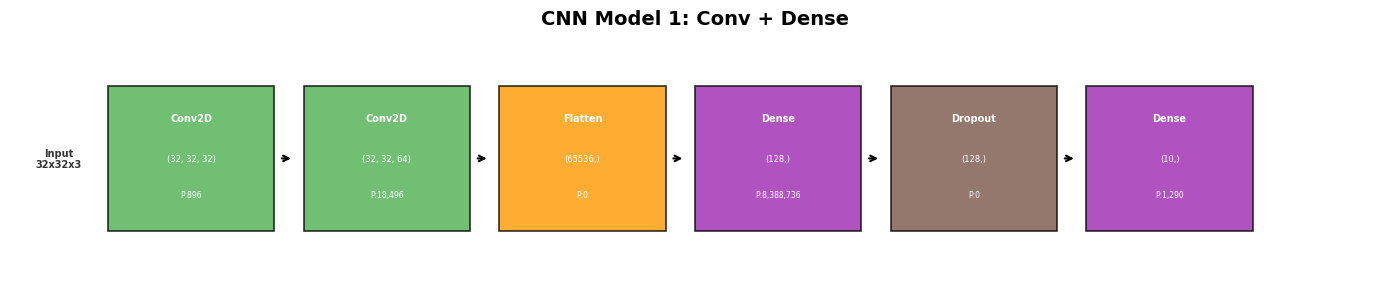

  CNN Model 1: Conv + Dense saved as 'assignment2_images/cnn1_architecture.png'


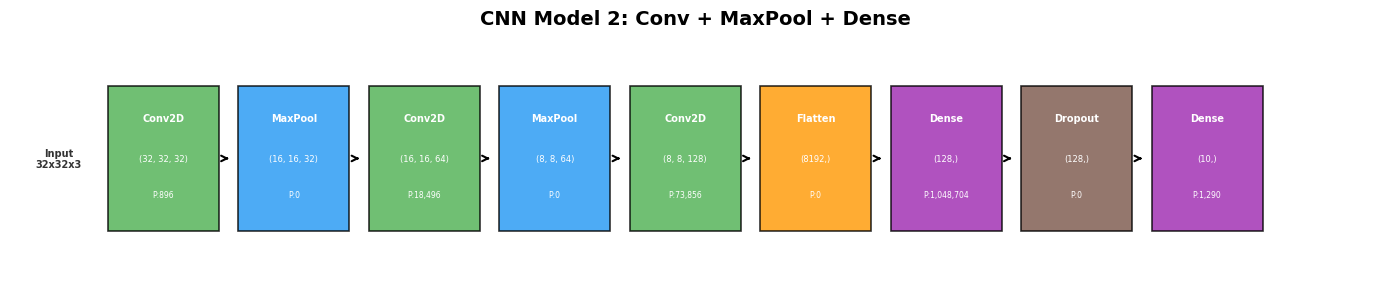

  CNN Model 2: Conv + MaxPool + Dense saved as 'assignment2_images/cnn2_architecture.png'


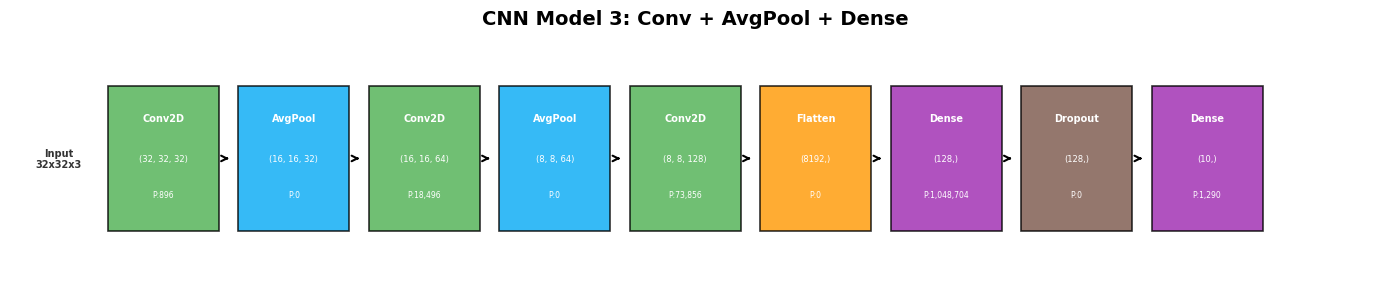

  CNN Model 3: Conv + AvgPool + Dense saved as 'assignment2_images/cnn3_architecture.png'


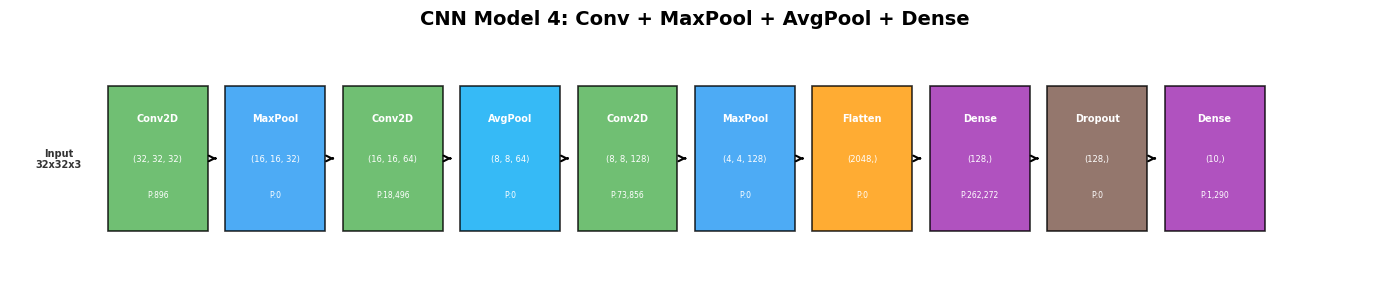

  CNN Model 4: Conv + MaxPool + AvgPool + Dense saved as 'assignment2_images/cnn4_architecture.png'



In [224]:
# ============================================================
# 步骤 11：CNN 架构图
# Step 11: CNN Architecture Diagrams
# ============================================================
print("=" * LINE_WIDTH)
print("Step 11: CNN Architecture Diagrams")
print("=" * LINE_WIDTH)


def draw_architecture(model, model_name, filename):
    """绘制模型架构图
    Draw model architecture diagram"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 3))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 3)
    ax.axis('off')
    ax.set_title(model_name, fontsize=14, fontweight='bold', pad=10)

    layer_info = []
    for layer in model.layers:
        name = layer.name
        output_shape = tuple(layer.output.shape)
        params = layer.count_params()
        if 'conv2d' in name:
            ltype = 'Conv2D'
            color = '#4CAF50'
        elif 'max_pooling' in name:
            ltype = 'MaxPool'
            color = '#2196F3'
        elif 'average_pooling' in name:
            ltype = 'AvgPool'
            color = '#03A9F4'
        elif 'flatten' in name:
            ltype = 'Flatten'
            color = '#FF9800'
        elif 'dense' in name:
            ltype = 'Dense'
            color = '#9C27B0'
        elif 'dropout' in name:
            ltype = 'Dropout'
            color = '#795548'
        else:
            ltype = name
            color = '#607D8B'
        layer_info.append((ltype, output_shape, params, color))

    n = len(layer_info)
    box_w = 12.0 / n
    start_x = 1.0

    for i, (ltype, shape, params, color) in enumerate(layer_info):
        x = start_x + i * box_w
        rect = plt.Rectangle((x, 0.6), box_w * 0.85, 1.8,
                              facecolor=color, edgecolor='black',
                              alpha=0.8, linewidth=1.2)
        ax.add_patch(rect)

        # 层类型名
        ax.text(x + box_w * 0.425, 2.0, ltype,
                ha='center', va='center', fontsize=7, fontweight='bold', color='white')

        # 输出形状
        shape_str = str(shape[1:]) if len(shape) > 1 else str(shape)
        ax.text(x + box_w * 0.425, 1.5, shape_str,
                ha='center', va='center', fontsize=6, color='white')

        # 参数数
        ax.text(x + box_w * 0.425, 1.05, f"P:{params:,}",
                ha='center', va='center', fontsize=5.5, color='white')

        # 箭头
        if i < n - 1:
            ax.annotate('', xy=(x + box_w * 0.85 + box_w * 0.1, 1.5),
                        xytext=(x + box_w * 0.85 + 0.05, 1.5),
                        arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

    # 输入标注
    ax.text(0.5, 1.5, 'Input\n32x32x3', ha='center', va='center', fontsize=7,
            fontweight='bold', color='#333')

    plt.tight_layout()
    plt.show()
    print(f"  {model_name} saved as 'assignment2_images/{filename}'")


draw_architecture(cnn1, "CNN Model 1: Conv + Dense", "cnn1_architecture.png")
draw_architecture(cnn2, "CNN Model 2: Conv + MaxPool + Dense", "cnn2_architecture.png")
draw_architecture(cnn3, "CNN Model 3: Conv + AvgPool + Dense", "cnn3_architecture.png")
draw_architecture(cnn4, "CNN Model 4: Conv + MaxPool + AvgPool + Dense", "cnn4_architecture.png")
print()

## Step 12: Results Summary - All Models Comparison

In [225]:
# ============================================================
# 步骤 12：结果汇总 - 所有模型比较
# Step 12: Results Summary - All Models Comparison
# ============================================================
print("=" * LINE_WIDTH)
print("Step 12: Results Summary - All Models Comparison")
print("=" * LINE_WIDTH)

summary_data = [
    ['MLP (sklearn)', f'{mlp_acc:.4f}', '50000', 'hidden=(256,128), relu, adam'],
    ['NN (Dense only)', f'{nn_acc:.4f}', '50000', 'Dense(512,256), relu, adam'],
    ['CNN Model 1', f'{cnn1_acc:.4f}', '50000', 'Conv+Dense (no pooling)'],
    ['CNN Model 2', f'{cnn2_acc:.4f}', '50000', 'Conv+MaxPool+Dense'],
    ['CNN Model 3', f'{cnn3_acc:.4f}', '50000', 'Conv+AvgPool+Dense'],
    ['CNN Model 4', f'{cnn4_acc:.4f}', '50000', 'Conv+MaxPool+AvgPool+Dense'],
]

summary_headers = ['Model', 'Test Accuracy', 'Train Size', 'Configuration']
print(tabulate(summary_data, headers=summary_headers, tablefmt='grid'))
print()

Step 12: Results Summary - All Models Comparison
+-----------------+-----------------+--------------+------------------------------+
| Model           |   Test Accuracy |   Train Size | Configuration                |
+=================+=================+==============+==============================+
| MLP (sklearn)   |          0.5153 |        50000 | hidden=(256,128), relu, adam |
+-----------------+-----------------+--------------+------------------------------+
| NN (Dense only) |          0.4103 |        50000 | Dense(512,256), relu, adam   |
+-----------------+-----------------+--------------+------------------------------+
| CNN Model 1     |          0.6235 |        50000 | Conv+Dense (no pooling)      |
+-----------------+-----------------+--------------+------------------------------+
| CNN Model 2     |          0.7212 |        50000 | Conv+MaxPool+Dense           |
+-----------------+-----------------+--------------+------------------------------+
| CNN Model 3     |        

## Step 13: Training History Visualization

Step 13: Training History Visualization


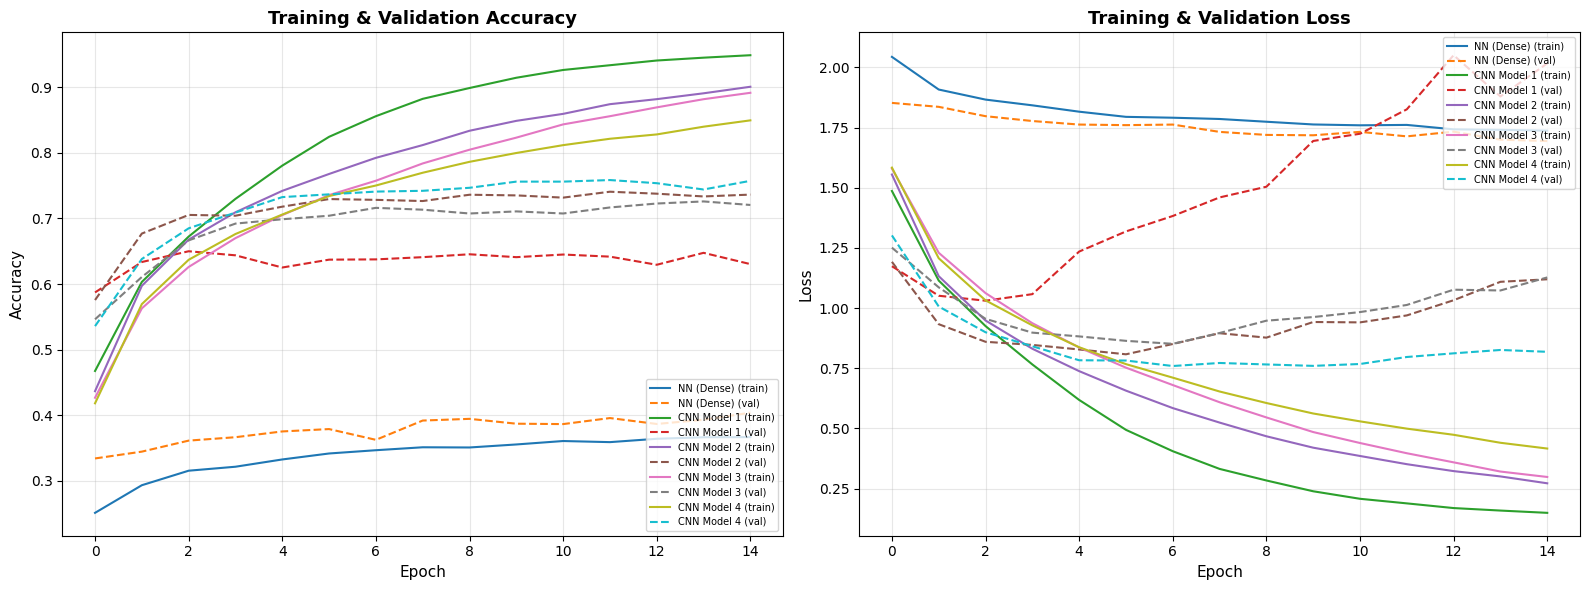

Training history saved as 'assignment2_images/training_history.png'



In [226]:
# ============================================================
# 步骤 13：训练历史可视化
# Step 13: Training History Visualization
# ============================================================
print("=" * LINE_WIDTH)
print("Step 13: Training History Visualization")
print("=" * LINE_WIDTH)

# 使用缓存的 history 数据（dict 格式）
# Use cached history data (dict format)
histories = {
    'NN (Dense)': nn_history_data,
    'CNN Model 1': cnn1_history_data,
    'CNN Model 2': cnn2_history_data,
    'CNN Model 3': cnn3_history_data,
    'CNN Model 4': cnn4_history_data,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, hist in histories.items():
    ax1.plot(hist['accuracy'], label=f'{name} (train)')
    ax1.plot(hist['val_accuracy'], label=f'{name} (val)', linestyle='--')

ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
ax1.legend(fontsize=7, loc='lower right')
ax1.grid(True, alpha=0.3)

for name, hist in histories.items():
    ax2.plot(hist['loss'], label=f'{name} (train)')
    ax2.plot(hist['val_loss'], label=f'{name} (val)', linestyle='--')

ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax2.legend(fontsize=7, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Training history saved as 'assignment2_images/training_history.png'")
print()

## Step 14: Parameter Study - Prepare Subset Data

In [227]:
# ============================================================
# 步骤 14：参数研究 - 准备子集数据
# Step 14: Parameter Study - Prepare Subset Data
# ============================================================
print("=" * LINE_WIDTH)
print("Step 14: Prepare Subset Data for Parameter Study")
print("=" * LINE_WIDTH)

# 参数研究不需要全量数据，使用子集加速训练
# Parameter study doesn't need full data, use subset to speed up
SUBSET_TRAIN = 5000
SUBSET_TEST = 1000

X_sub_train_flat = X_train_flat[:SUBSET_TRAIN]
X_sub_test_flat = X_test_flat[:SUBSET_TEST]
X_sub_train = X_train_norm[:SUBSET_TRAIN]
X_sub_test = X_test_norm[:SUBSET_TEST]
y_sub_train_flat = y_train_flat[:SUBSET_TRAIN]
y_sub_test_flat = y_test_flat[:SUBSET_TEST]
y_sub_train_oh = y_train_onehot[:SUBSET_TRAIN]
y_sub_test_oh = y_test_onehot[:SUBSET_TEST]

print(f"Subset: {SUBSET_TRAIN} train, {SUBSET_TEST} test (from 50000/10000)")
print()

Step 14: Prepare Subset Data for Parameter Study
Subset: 5000 train, 1000 test (from 50000/10000)



## Parameter Study Helper Functions

In [228]:
# ============================================================
# 参数研究辅助函数
# Parameter Study Helper Functions
# ============================================================
def plot_param_comparison(results, param_name, filename, prefix=''):
    """绘制参数对比柱状图 / Plot parameter comparison bar chart"""
    labels = list(results.keys())
    accs = list(results.values())
    n = len(labels)
    cmap = plt.cm.Set2
    colors = [cmap(i / max(n - 1, 1)) for i in range(n)]
    fig, ax = plt.subplots(figsize=(max(8, n * 2), 5))
    bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{acc:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel('Test Accuracy', fontsize=12)
    title = f'{prefix} — Effect of {param_name} on CIFAR-10' if prefix else f'Effect of {param_name} on CIFAR-10'
    ax.set_title(title, fontsize=14, fontweight='bold')
    min_acc = min(accs)
    ax.set_ylim(max(0, min_acc - 0.08), min(1.0, max(accs) + 0.05))
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    print(f"  Chart saved: assignment2_images/{filename}")


def train_mlp_param(params, cache_name):
    """训练 MLP 并返回准确率（带缓存）/ Train MLP with caching"""
    cache_file = CACHE_DIR / f'mlp_param_{cache_name}.pkl'
    if cache_file.exists():
        with open(cache_file, 'rb') as f:
            return pickle.load(f)
    m = MLPClassifier(random_state=RANDOM_STATE, verbose=False, **params)
    m.fit(X_sub_train_flat, y_sub_train_flat)
    acc = accuracy_score(y_sub_test_flat, m.predict(X_sub_test_flat))
    with open(cache_file, 'wb') as f:
        pickle.dump(acc, f)
    return acc


def run_mlp_experiment(param_name, options, baseline, label_fn=None):
    """MLP 单参数实验 / MLP single-parameter experiment"""
    results = {}
    for opt in options:
        params = dict(baseline)
        params[param_name] = opt
        label = label_fn(opt) if label_fn else str(opt)
        cache_name = f"{param_name}_{label}".replace(' ', '_').replace(',', '_')
        print(f"  Training: {param_name}={label} ...", end=" ", flush=True)
        acc = train_mlp_param(params, cache_name)
        results[label] = acc
        print(f"Accuracy = {acc:.4f}")
    return results


def train_keras_param(build_fn, y_tr, y_te, cache_suffix,
                      epochs=5, batch_size=64, validation_split=0.1):
    """训练 Keras 模型并返回准确率（带缓存）/ Train Keras model with caching"""
    cache_file = CACHE_DIR / f'keras_param_{cache_suffix}_acc.pkl'
    if cache_file.exists():
        with open(cache_file, 'rb') as f:
            return pickle.load(f)
    model = build_fn()
    model.fit(X_sub_train, y_tr, epochs=epochs, batch_size=batch_size,
              validation_split=validation_split, verbose=0)
    _, acc = model.evaluate(X_sub_test, y_te, verbose=0)
    with open(cache_file, 'wb') as f:
        pickle.dump(acc, f)
    return acc

## Step 15: MLP Parameter Study (sklearn MLPClassifier)

Step 15: MLP Parameter Study (6 parameters)
Baseline: {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'batch_size': 256, 'learning_rate_init': 0.001, 'max_iter': 30}

--- Activation Function Calculations ---
Each activation function transforms inputs differently:

1. ReLU (Rectified Linear Unit):
   f(x) = max(0, x)
   Example: f(3.5) = 3.5, f(-2.0) = 0
   Advantage: Fast, avoids vanishing gradient for positive values

2. Tanh (Hyperbolic Tangent):
   f(x) = (e^x - e^{-x}) / (e^x + e^{-x})
   Output range: [-1, 1], zero-centered
   Example: f(0) = 0, f(1) = 0.76, f(-1) = -0.76

3. Sigmoid / Logistic:
   f(x) = 1 / (1 + e^{-x})
   Output range: [0, 1], used for probabilities
   Example: f(0) = 0.5, f(2) = 0.88, f(-2) = 0.12

4. Softmax (multi-class output layer):
   f(x_i) = e^{x_i} / sum(e^{x_j}) for all j
   Outputs sum to 1.0, interpreted as class probabilities
   Example: softmax([2,1,0]) = [0.67, 0.24, 0.09]

--- 15.1 hidden_layer_sizes ---
  Training: hi

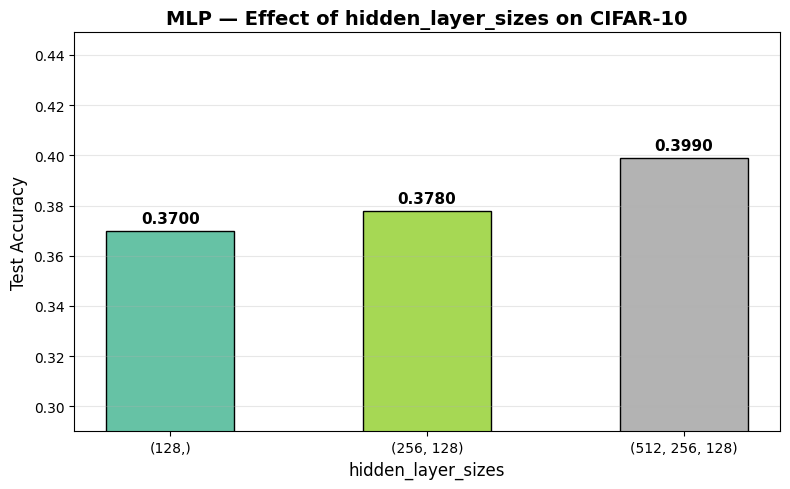

  Chart saved: assignment2_images/mlp_hidden_layer_sizes.png
--- 15.2 activation ---
  Training: activation=relu ... Accuracy = 0.3780
  Training: activation=tanh ... Accuracy = 0.3730
  Training: activation=logistic ... Accuracy = 0.3810


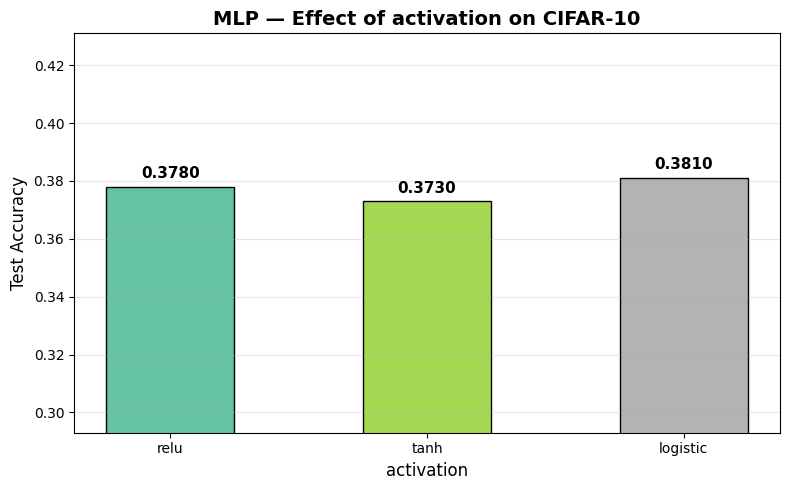

  Chart saved: assignment2_images/mlp_activation.png
--- 15.3 solver ---
  Training: solver=adam ... Accuracy = 0.3780
  Training: solver=sgd ... Accuracy = 0.3600
  Training: solver=lbfgs ... Accuracy = 0.3530


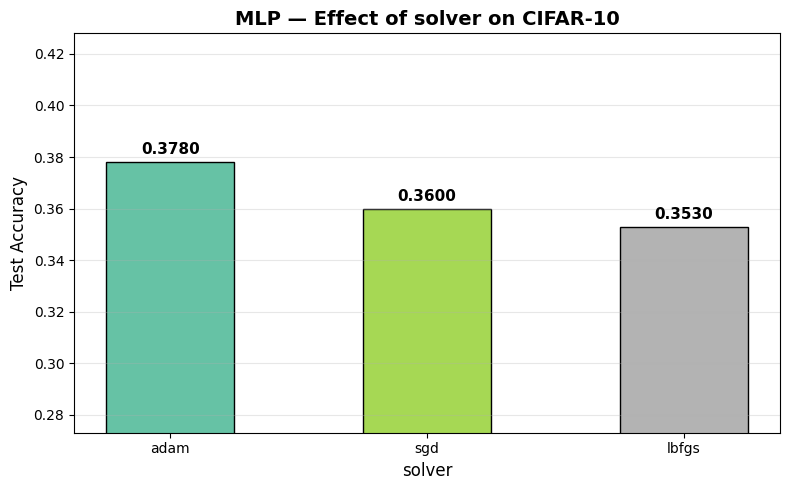

  Chart saved: assignment2_images/mlp_solver.png
--- 15.4 batch_size ---
  Training: batch_size=32 ... Accuracy = 0.4050
  Training: batch_size=64 ... Accuracy = 0.3850
  Training: batch_size=128 ... Accuracy = 0.3660
  Training: batch_size=256 ... Accuracy = 0.3780


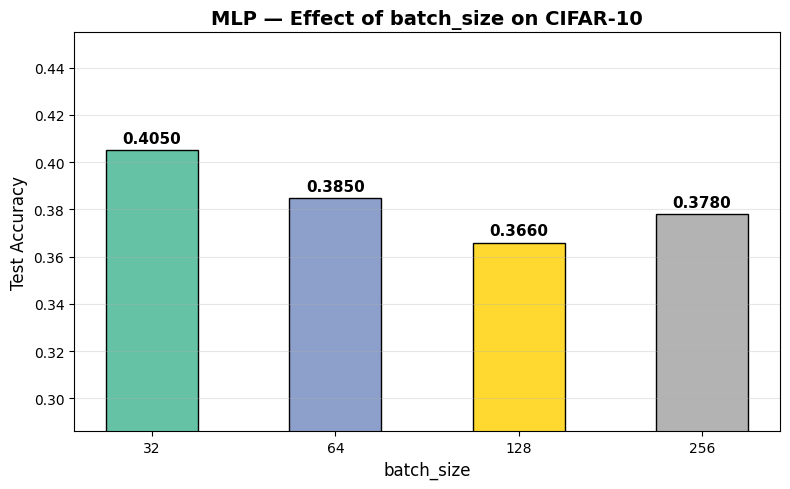

  Chart saved: assignment2_images/mlp_batch_size.png
--- 15.5 learning_rate_init ---
  Training: learning_rate_init=0.0001 ... Accuracy = 0.3910
  Training: learning_rate_init=0.001 ... Accuracy = 0.3780
  Training: learning_rate_init=0.01 ... Accuracy = 0.3430


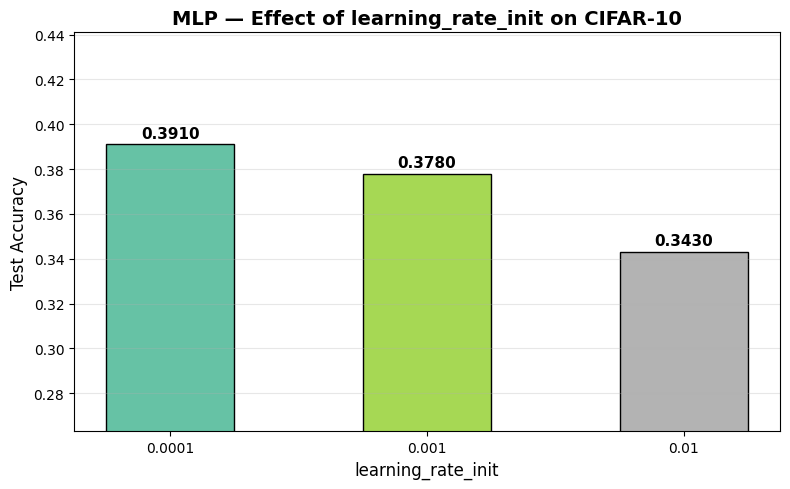

  Chart saved: assignment2_images/mlp_learning_rate.png
--- 15.6 max_iter ---
  Training: max_iter=10 ... Accuracy = 0.3580
  Training: max_iter=30 ... Accuracy = 0.3780
  Training: max_iter=50 ... Accuracy = 0.4080
  Training: max_iter=100 ... Accuracy = 0.4040


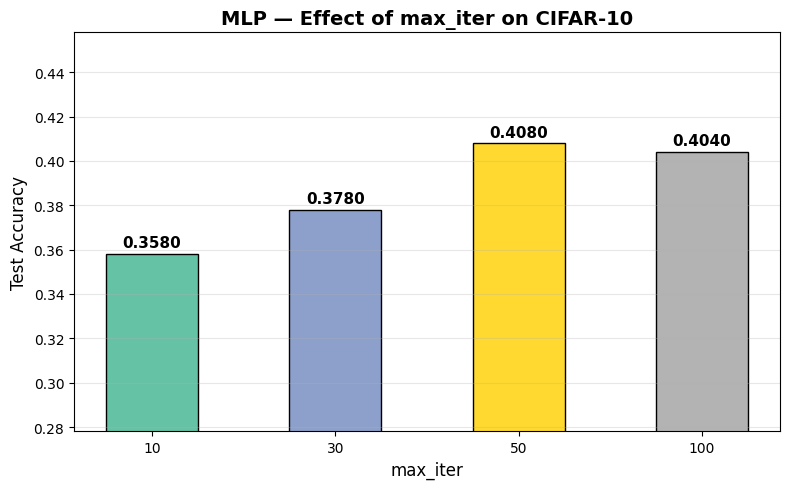

  Chart saved: assignment2_images/mlp_max_iter.png



In [229]:
# ============================================================
# 步骤 15：MLP 参数研究（sklearn MLPClassifier）
# Step 15: MLP Parameter Study (sklearn MLPClassifier)
# ============================================================
print("=" * LINE_WIDTH)
print("Step 15: MLP Parameter Study (6 parameters)")
print("=" * LINE_WIDTH)

# MLP 基线参数（控制变量法：每次只改一个参数）
# MLP baseline (control variable: change one at a time)
MLP_BASELINE = {
    'hidden_layer_sizes': (256, 128),
    'activation': 'relu',
    'solver': 'adam',
    'batch_size': 256,
    'learning_rate_init': 0.001,
    'max_iter': 30,
}
print(f"Baseline: {MLP_BASELINE}\n")

# 17.1 hidden_layer_sizes — 隐藏层结构
print("--- Activation Function Calculations ---")
print("""Each activation function transforms inputs differently:

1. ReLU (Rectified Linear Unit):
   f(x) = max(0, x)
   Example: f(3.5) = 3.5, f(-2.0) = 0
   Advantage: Fast, avoids vanishing gradient for positive values

2. Tanh (Hyperbolic Tangent):
   f(x) = (e^x - e^{-x}) / (e^x + e^{-x})
   Output range: [-1, 1], zero-centered
   Example: f(0) = 0, f(1) = 0.76, f(-1) = -0.76

3. Sigmoid / Logistic:
   f(x) = 1 / (1 + e^{-x})
   Output range: [0, 1], used for probabilities
   Example: f(0) = 0.5, f(2) = 0.88, f(-2) = 0.12

4. Softmax (multi-class output layer):
   f(x_i) = e^{x_i} / sum(e^{x_j}) for all j
   Outputs sum to 1.0, interpreted as class probabilities
   Example: softmax([2,1,0]) = [0.67, 0.24, 0.09]
""")
print("--- 15.1 hidden_layer_sizes ---")
mlp_hidden_results = run_mlp_experiment(
    'hidden_layer_sizes',
    [(128,), (256, 128), (512, 256, 128)],
    MLP_BASELINE, label_fn=str)
plot_param_comparison(mlp_hidden_results, 'hidden_layer_sizes', 'mlp_hidden_layer_sizes.png', 'MLP')

# 15.2 activation — 激活函数
print("--- 15.2 activation ---")
mlp_act_results = run_mlp_experiment('activation', ['relu', 'tanh', 'logistic'], MLP_BASELINE)
plot_param_comparison(mlp_act_results, 'activation', 'mlp_activation.png', 'MLP')

# 15.3 solver — 优化器
print("--- 15.3 solver ---")
mlp_solver_results = run_mlp_experiment('solver', ['adam', 'sgd', 'lbfgs'], MLP_BASELINE)
plot_param_comparison(mlp_solver_results, 'solver', 'mlp_solver.png', 'MLP')

# 15.4 batch_size — 批大小
print("--- 15.4 batch_size ---")
mlp_bs_results = run_mlp_experiment('batch_size', [32, 64, 128, 256], MLP_BASELINE)
plot_param_comparison(mlp_bs_results, 'batch_size', 'mlp_batch_size.png', 'MLP')

# 15.5 learning_rate_init — 初始学习率
print("--- 15.5 learning_rate_init ---")
mlp_lr_results = run_mlp_experiment('learning_rate_init', [0.0001, 0.001, 0.01], MLP_BASELINE)
plot_param_comparison(mlp_lr_results, 'learning_rate_init', 'mlp_learning_rate.png', 'MLP')

# 15.6 max_iter — 最大迭代次数
print("--- 15.6 max_iter ---")
mlp_iter_results = run_mlp_experiment('max_iter', [10, 30, 50, 100], MLP_BASELINE)
plot_param_comparison(mlp_iter_results, 'max_iter', 'mlp_max_iter.png', 'MLP')

mlp_all_params = [
    ('hidden_layer_sizes', mlp_hidden_results),
    ('activation', mlp_act_results),
    ('solver', mlp_solver_results),
    ('batch_size', mlp_bs_results),
    ('learning_rate_init', mlp_lr_results),
    ('max_iter', mlp_iter_results),
]
print()

## Step 16: Dense NN Parameter Study (Keras)

Step 16: Dense NN Parameter Study (2 parameters)
Baseline: Dense(512,relu) -> Dense(256,relu) -> Dense(10,softmax)

--- 16.1 units (hidden layer structure) ---
  Training: units=(256,) ... Accuracy = 0.3290
  Training: units=(512,256) ... Accuracy = 0.3040
  Training: units=(512,256,128) ... Accuracy = 0.3140


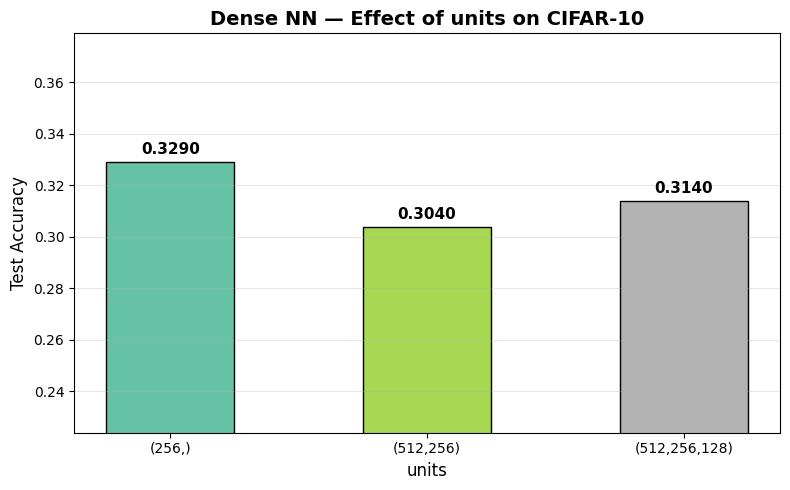

  Chart saved: assignment2_images/dense_units.png
--- 16.2 activation ---
  Training: activation=relu ... Accuracy = 0.3300
  Training: activation=tanh ... Accuracy = 0.2750
  Training: activation=sigmoid ... Accuracy = 0.3170


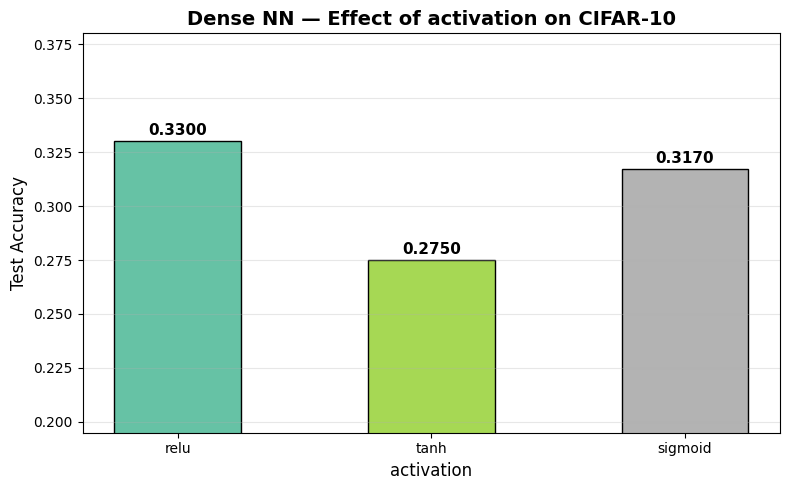

  Chart saved: assignment2_images/dense_activation.png



In [230]:
# ============================================================
# 步骤 16：Dense NN 参数研究（Keras）
# Step 16: Dense NN Parameter Study (Keras)
# ============================================================
print("=" * LINE_WIDTH)
print("Step 16: Dense NN Parameter Study (2 parameters)")
print("=" * LINE_WIDTH)
print("Baseline: Dense(512,relu) -> Dense(256,relu) -> Dense(10,softmax)\n")


def build_dense_model(layer_units, activation='relu'):
    """构建全连接模型 / Build Dense model"""
    m = models.Sequential()
    m.add(layers.Flatten(input_shape=(32, 32, 3)))
    for u in layer_units:
        m.add(layers.Dense(u, activation=activation))
        m.add(layers.Dropout(0.3))
    m.add(layers.Dense(10, activation='softmax'))
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m


# 18.1 units — 隐藏层神经元数量
print("--- 16.1 units (hidden layer structure) ---")
dense_units_configs = {'(256,)': [256], '(512,256)': [512, 256], '(512,256,128)': [512, 256, 128]}
dense_units_results = {}
for label, lu in dense_units_configs.items():
    print(f"  Training: units={label} ...", end=" ", flush=True)
    acc = train_keras_param(
        lambda l=lu: build_dense_model(l, 'relu'),
        y_sub_train_oh, y_sub_test_oh, f"dense_units_{label}", epochs=10)
    dense_units_results[label] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(dense_units_results, 'units', 'dense_units.png', 'Dense NN')

# 18.2 activation — 激活函数
print("--- 16.2 activation ---")
dense_act_results = {}
for act in ['relu', 'tanh', 'sigmoid']:
    print(f"  Training: activation={act} ...", end=" ", flush=True)
    acc = train_keras_param(
        lambda a=act: build_dense_model([512, 256], a),
        y_sub_train_oh, y_sub_test_oh, f"dense_act_{act}", epochs=10)
    dense_act_results[act] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(dense_act_results, 'activation', 'dense_activation.png', 'Dense NN')

dense_all_params = [
    ('units', dense_units_results),
    ('activation', dense_act_results),
]
print()

## Step 17: CNN Parameter Study — Conv2D Layer Parameters

Step 17: CNN Parameter Study — Conv2D (6 parameters)
Baseline: Conv2D(32,3x3,same,relu) -> MaxPool -> Conv2D(64) -> MaxPool

--- 17.1 filters ---
  Training: filters=16->32 ... Accuracy = 0.4840
  Training: filters=32->64 ... Accuracy = 0.4780
  Training: filters=64->128 ... Accuracy = 0.4910


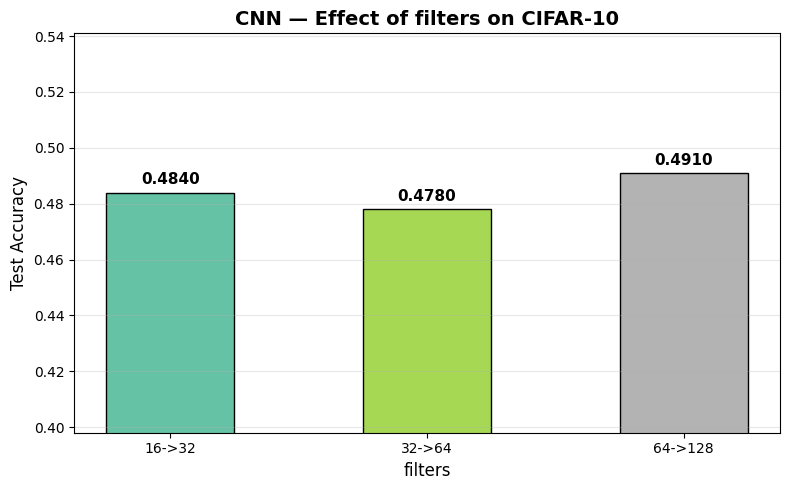

  Chart saved: assignment2_images/cnn_filters.png
--- 17.2 kernel_size ---
  Training: kernel_size=3x3 ... Accuracy = 0.4840
  Training: kernel_size=5x5 ... Accuracy = 0.4700
  Training: kernel_size=7x7 ... Accuracy = 0.4310


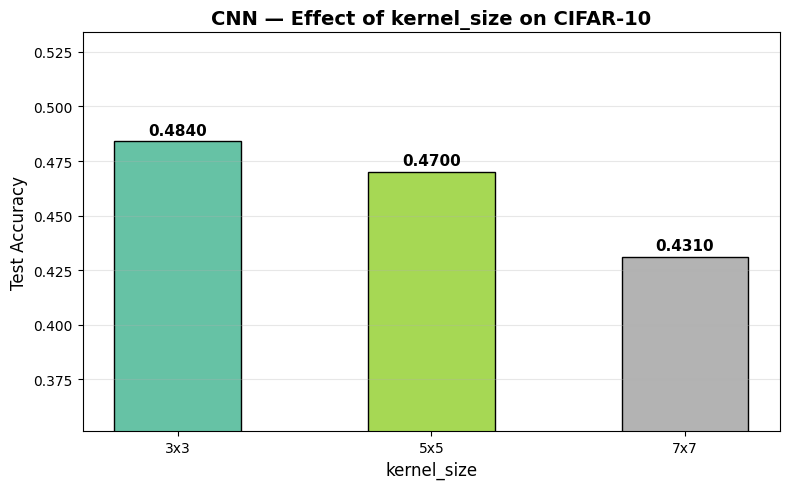

  Chart saved: assignment2_images/cnn_kernel_size.png
--- 17.3 strides ---
  Training: strides=(1,1) ... Accuracy = 0.4960
  Training: strides=(2,2) ... Accuracy = 0.4300


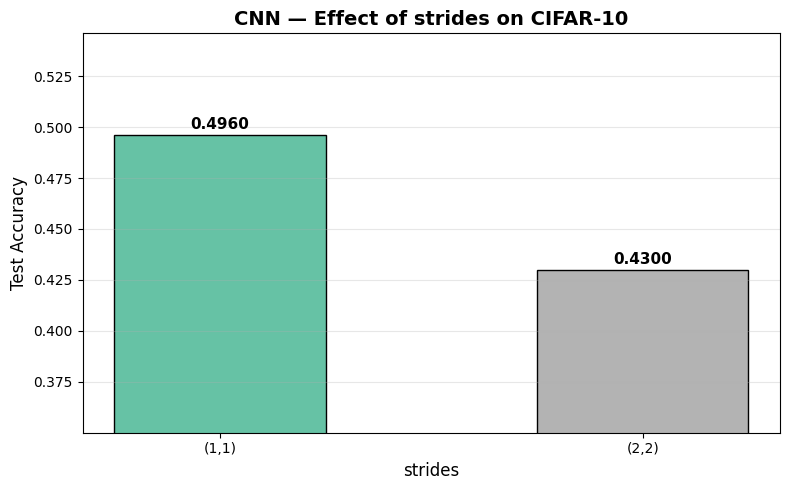

  Chart saved: assignment2_images/cnn_strides.png
--- 17.4 padding ---
  Training: padding=same ... Accuracy = 0.4950
  Training: padding=valid ... Accuracy = 0.4600


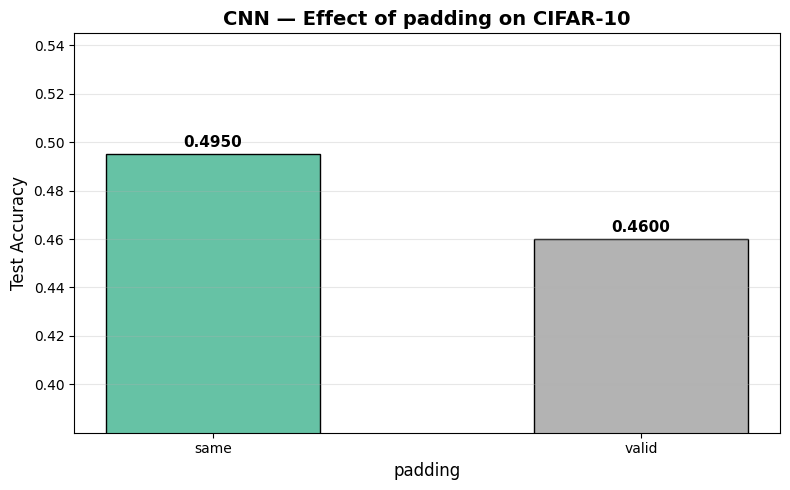

  Chart saved: assignment2_images/cnn_padding.png
--- 17.5 activation (conv layers) ---
  Training: activation=relu ... Accuracy = 0.4990
  Training: activation=tanh ... Accuracy = 0.4690
  Training: activation=sigmoid ... Accuracy = 0.0900


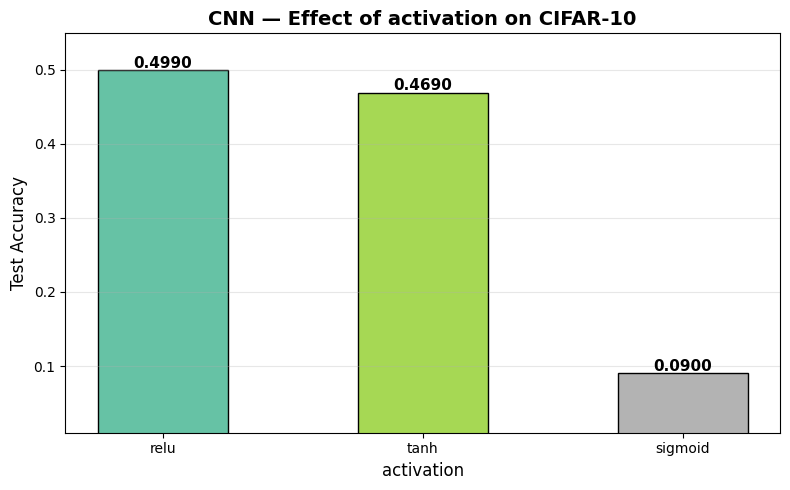

  Chart saved: assignment2_images/cnn_activation.png
--- 17.6 input_shape ---
  Training: input_shape=16x16x3 ... Accuracy = 0.4360
  Training: input_shape=32x32x3 ... Accuracy = 0.4950
  Training: input_shape=48x48x3 ... Accuracy = 0.4560


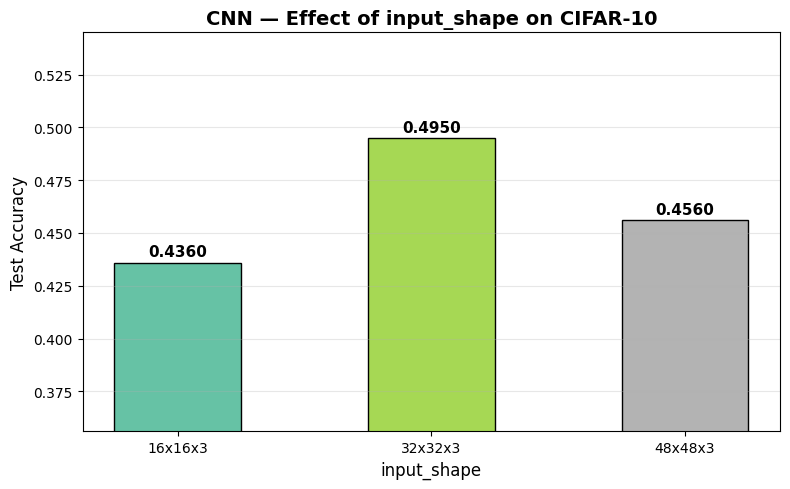

  Chart saved: assignment2_images/cnn_input_shape.png



In [231]:
# ============================================================
# 步骤 17：CNN 参数研究 — Conv2D 层参数（Keras）
# Step 17: CNN Parameter Study — Conv2D Layer Parameters
# ============================================================
print("=" * LINE_WIDTH)
print("Step 17: CNN Parameter Study — Conv2D (6 parameters)")
print("=" * LINE_WIDTH)
print("Baseline: Conv2D(32,3x3,same,relu) -> MaxPool -> Conv2D(64) -> MaxPool\n")


def build_cnn_model(filters=(32, 64), kernel_size=3, strides=1,
                    padding='same', conv_activation='relu',
                    optimizer='adam', loss='categorical_crossentropy', lr=None):
    """构建 CNN 模型 / Build CNN model"""
    m = models.Sequential([
        layers.Conv2D(filters[0], (kernel_size, kernel_size),
                      strides=(strides, strides), padding=padding,
                      activation=conv_activation, input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters[1], (kernel_size, kernel_size),
                      padding=padding, activation=conv_activation),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    opt = keras.optimizers.Adam(learning_rate=lr) if lr else optimizer
    m.compile(optimizer=opt, loss=loss, metrics=['accuracy'])
    return m


# 19.1 filters — 滤波器数量
print("--- 17.1 filters ---")
cnn_filter_results = {}
for label, fp in [('16->32', (16, 32)), ('32->64', (32, 64)), ('64->128', (64, 128))]:
    print(f"  Training: filters={label} ...", end=" ", flush=True)
    acc = train_keras_param(lambda f=fp: build_cnn_model(filters=f),
                            y_sub_train_oh, y_sub_test_oh, f"cnn_filters_{label.replace('->','_')}")
    cnn_filter_results[label] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_filter_results, 'filters', 'cnn_filters.png', 'CNN')

# 17.2 kernel_size — 卷积核大小
print("--- 17.2 kernel_size ---")
cnn_ks_results = {}
for ks in [3, 5, 7]:
    print(f"  Training: kernel_size={ks}x{ks} ...", end=" ", flush=True)
    acc = train_keras_param(lambda k=ks: build_cnn_model(kernel_size=k),
                            y_sub_train_oh, y_sub_test_oh, f"cnn_kernel_{ks}")
    cnn_ks_results[f'{ks}x{ks}'] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_ks_results, 'kernel_size', 'cnn_kernel_size.png', 'CNN')

# 17.3 strides — 步长
print("--- 17.3 strides ---")
cnn_stride_results = {}
for s in [1, 2]:
    print(f"  Training: strides=({s},{s}) ...", end=" ", flush=True)
    acc = train_keras_param(lambda st=s: build_cnn_model(strides=st),
                            y_sub_train_oh, y_sub_test_oh, f"cnn_strides_{s}")
    cnn_stride_results[f'({s},{s})'] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_stride_results, 'strides', 'cnn_strides.png', 'CNN')

# 17.4 padding — 填充方式
print("--- 17.4 padding ---")
cnn_pad_results = {}
for pad in ['same', 'valid']:
    print(f"  Training: padding={pad} ...", end=" ", flush=True)
    acc = train_keras_param(lambda p=pad: build_cnn_model(padding=p),
                            y_sub_train_oh, y_sub_test_oh, f"cnn_padding_{pad}")
    cnn_pad_results[pad] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_pad_results, 'padding', 'cnn_padding.png', 'CNN')

# 17.5 activation — 卷积层激活函数
print("--- 17.5 activation (conv layers) ---")
cnn_act_results = {}
for act in ['relu', 'tanh', 'sigmoid']:
    print(f"  Training: activation={act} ...", end=" ", flush=True)
    acc = train_keras_param(lambda a=act: build_cnn_model(conv_activation=a),
                            y_sub_train_oh, y_sub_test_oh, f"cnn_conv_act_{act}")
    cnn_act_results[act] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_act_results, 'activation', 'cnn_activation.png', 'CNN')

# 17.6 input_shape — 输入形状（不同分辨率）
# 17.6 input_shape — effect of different image resolutions
print("--- 17.6 input_shape ---")
cnn_input_results = {}
for size, label in [(16, '16x16x3'), (32, '32x32x3'), (48, '48x48x3')]:
    print(f"  Training: input_shape={label} ...", end=" ", flush=True)
    cache_file = CACHE_DIR / f'keras_param_cnn_input_{size}_acc.pkl'
    if cache_file.exists():
        with open(cache_file, 'rb') as f:
            acc = pickle.load(f)
    else:
        X_tr_resized = tf.image.resize(X_sub_train, (size, size)).numpy()
        X_te_resized = tf.image.resize(X_sub_test, (size, size)).numpy()
        m = models.Sequential([
            layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                          input_shape=(size, size, 3)),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.MaxPooling2D((2, 2)),
            layers.Flatten(),
            layers.Dense(64, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        m.fit(X_tr_resized, y_sub_train_oh, epochs=5, batch_size=64,
              validation_split=0.1, verbose=0)
        _, acc = m.evaluate(X_te_resized, y_sub_test_oh, verbose=0)
        with open(cache_file, 'wb') as f:
            pickle.dump(acc, f)
    cnn_input_results[label] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_input_results, 'input_shape', 'cnn_input_shape.png', 'CNN')
print()

## Step 18: CNN Parameter Study — Compile Parameters

In [232]:
# ============================================================
# 步骤 18：CNN 参数研究 — Compile 参数
# Step 18: CNN Parameter Study — Compile Parameters
# ============================================================
print("=" * LINE_WIDTH)
print("Step 18: CNN Parameter Study — Compile (3 parameters)")
print("=" * LINE_WIDTH)

Step 18: CNN Parameter Study — Compile (3 parameters)


## Explanation of Compile and Fit Methods

--- Role of Compile and Fit Methods ---
model.compile() — Configure training process (does NOT train):
  - optimizer: Weight update algorithm (adam, sgd, rmsprop)
  - loss: Error measurement function (crossentropy, mse)
  - metrics: What to monitor during training (accuracy, precision, AUC)
  compile() prepares the model by linking optimizer, loss, and metrics.

model.fit() — Execute the actual training:
  - X, y: Training data and labels
  - epochs: Number of full passes through the training data
  - batch_size: Samples per gradient update
  - validation_split: Auto-split fraction for validation
  - validation_data: Explicit (X_val, y_val) for validation
  fit() performs forward pass, loss calculation, backpropagation, and weight update.

--- 18.1 optimizer ---
  Training: optimizer=adam ... Accuracy = 0.4700
  Training: optimizer=sgd ... Accuracy = 0.2400
  Training: optimizer=rmsprop ... Accuracy = 0.4690


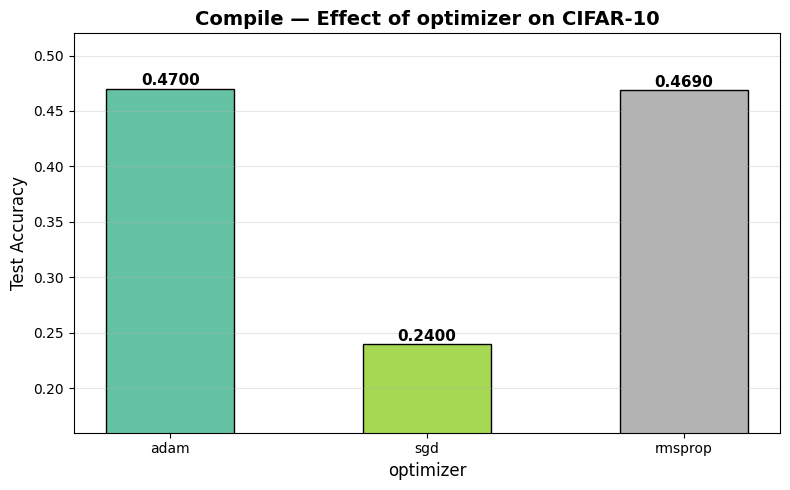

  Chart saved: assignment2_images/cnn_optimizer.png
--- 18.2 loss function ---
  Training: loss=categorical_CE ... Accuracy = 0.5220
  Training: loss=sparse_cat_CE ... Accuracy = 0.4800
  Training: loss=mse ... Accuracy = 0.4660


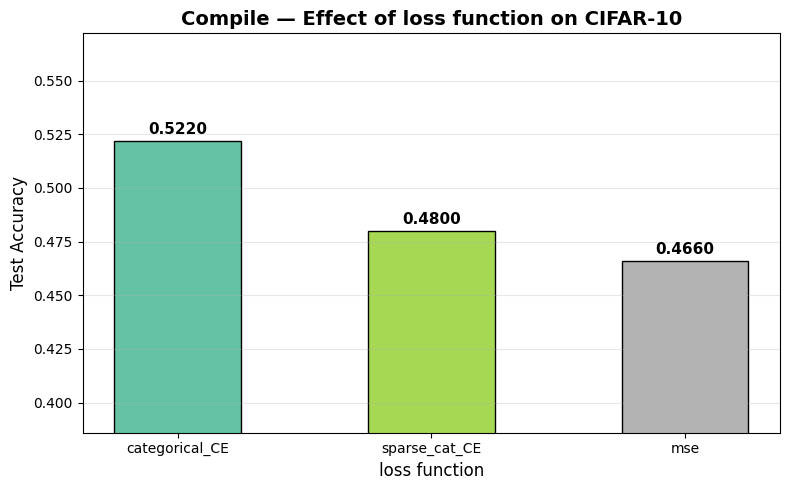

  Chart saved: assignment2_images/cnn_loss.png
--- 18.3 metrics ---
  Note: metrics does not affect training, only what is monitored.
  Compile with metrics=['accuracy'] ... Accuracy = 0.4680
  Compile with metrics=['precision'] ... Accuracy = 0.4860
  Compile with metrics=['recall'] ... Accuracy = 0.4990
  Compile with metrics=['AUC'] ... Accuracy = 0.4890


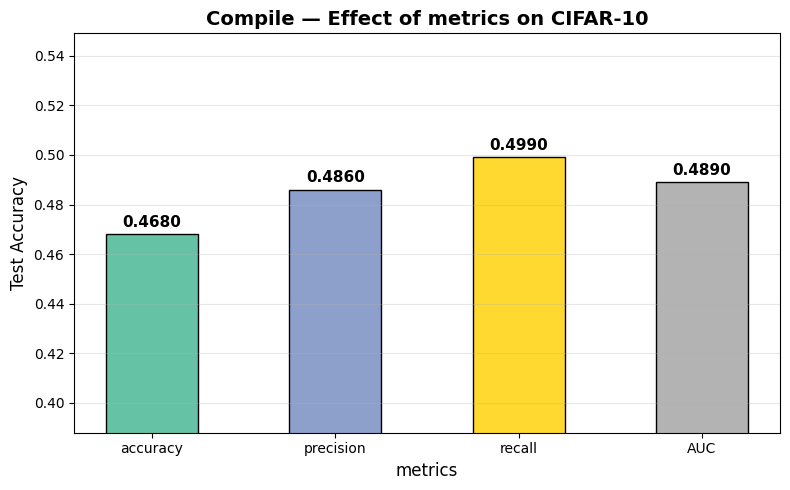

  Chart saved: assignment2_images/cnn_metrics.png



In [233]:
# ================================================================
# Compile 和 Fit 方法说明
# Explanation of Compile and Fit Methods
# ================================================================
print("--- Role of Compile and Fit Methods ---")
print("""model.compile() — Configure training process (does NOT train):
  - optimizer: Weight update algorithm (adam, sgd, rmsprop)
  - loss: Error measurement function (crossentropy, mse)
  - metrics: What to monitor during training (accuracy, precision, AUC)
  compile() prepares the model by linking optimizer, loss, and metrics.

model.fit() — Execute the actual training:
  - X, y: Training data and labels
  - epochs: Number of full passes through the training data
  - batch_size: Samples per gradient update
  - validation_split: Auto-split fraction for validation
  - validation_data: Explicit (X_val, y_val) for validation
  fit() performs forward pass, loss calculation, backpropagation, and weight update.
""")

# 20.1 optimizer — 优化器
print("--- 18.1 optimizer ---")
cnn_opt_results = {}
for opt in ['adam', 'sgd', 'rmsprop']:
    print(f"  Training: optimizer={opt} ...", end=" ", flush=True)
    acc = train_keras_param(lambda o=opt: build_cnn_model(optimizer=o),
                            y_sub_train_oh, y_sub_test_oh, f"cnn_opt_{opt}")
    cnn_opt_results[opt] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_opt_results, 'optimizer', 'cnn_optimizer.png', 'Compile')

# 18.2 loss — 损失函数
print("--- 18.2 loss function ---")
cnn_loss_results = {}
# categorical_crossentropy (one-hot labels)
print(f"  Training: loss=categorical_CE ...", end=" ", flush=True)
acc = train_keras_param(lambda: build_cnn_model(loss='categorical_crossentropy'),
                        y_sub_train_oh, y_sub_test_oh, "cnn_loss_cat_ce")
cnn_loss_results['categorical_CE'] = acc
print(f"Accuracy = {acc:.4f}")

# sparse_categorical_crossentropy (integer labels)
print(f"  Training: loss=sparse_cat_CE ...", end=" ", flush=True)
acc = train_keras_param(lambda: build_cnn_model(loss='sparse_categorical_crossentropy'),
                        y_sub_train_flat, y_sub_test_flat, "cnn_loss_sparse_ce")
cnn_loss_results['sparse_cat_CE'] = acc
print(f"Accuracy = {acc:.4f}")

# mse (mean squared error)
print(f"  Training: loss=mse ...", end=" ", flush=True)
acc = train_keras_param(lambda: build_cnn_model(loss='mse'),
                        y_sub_train_oh, y_sub_test_oh, "cnn_loss_mse")
cnn_loss_results['mse'] = acc
print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_loss_results, 'loss function', 'cnn_loss.png', 'Compile')

# 18.3 metrics — 评估指标
# 18.3 metrics — evaluation metrics (does not affect training)
print("--- 18.3 metrics ---")
print("  Note: metrics does not affect training, only what is monitored.")
cnn_metrics_results = {}
metrics_configs = [
    ('accuracy', ['accuracy']),
    ('precision', [keras.metrics.Precision(name='precision')]),
    ('recall', [keras.metrics.Recall(name='recall')]),
    ('AUC', [keras.metrics.AUC(name='auc')]),
]
for label, ml in metrics_configs:
    print(f"  Compile with metrics=['{label}'] ...", end=" ", flush=True)
    cache_file = CACHE_DIR / f'keras_param_cnn_metrics_{label}_acc.pkl'
    if cache_file.exists():
        with open(cache_file, 'rb') as f:
            acc = pickle.load(f)
    else:
        m = build_cnn_model()
        m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=ml)
        m.fit(X_sub_train, y_sub_train_oh, epochs=5, batch_size=64,
              validation_split=0.1, verbose=0)
        y_pred = np.argmax(m.predict(X_sub_test, verbose=0), axis=1)
        acc = accuracy_score(y_sub_test_flat, y_pred)
        with open(cache_file, 'wb') as f:
            pickle.dump(acc, f)
    cnn_metrics_results[label] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_metrics_results, 'metrics', 'cnn_metrics.png', 'Compile')
print()

## Step 19: CNN Parameter Study — Fit Parameters

Step 19: CNN Parameter Study — Fit (5 parameters)
--- 19.1 epochs ---
  Training: epochs=3 ... Accuracy = 0.4360
  Training: epochs=5 ... Accuracy = 0.4860
  Training: epochs=10 ... Accuracy = 0.5490
  Training: epochs=15 ... Accuracy = 0.5510


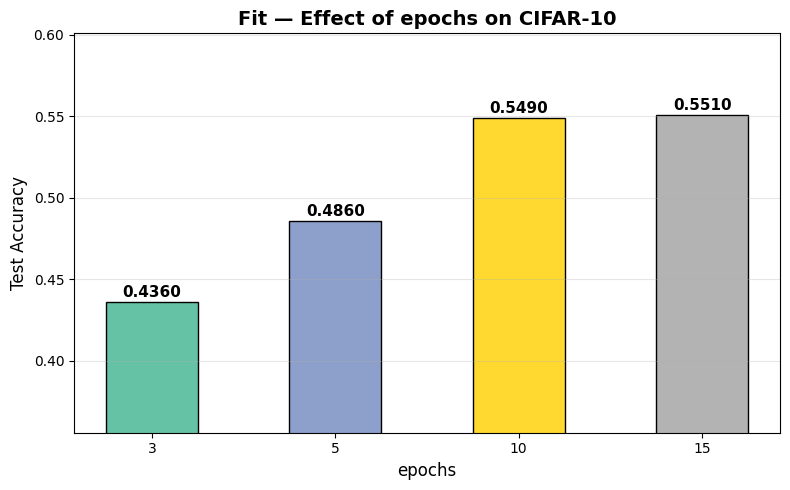

  Chart saved: assignment2_images/cnn_epochs.png
--- 19.2 batch_size ---
  Training: batch_size=32 ... Accuracy = 0.5220
  Training: batch_size=64 ... Accuracy = 0.4620
  Training: batch_size=128 ... Accuracy = 0.4380
  Training: batch_size=256 ... Accuracy = 0.4200


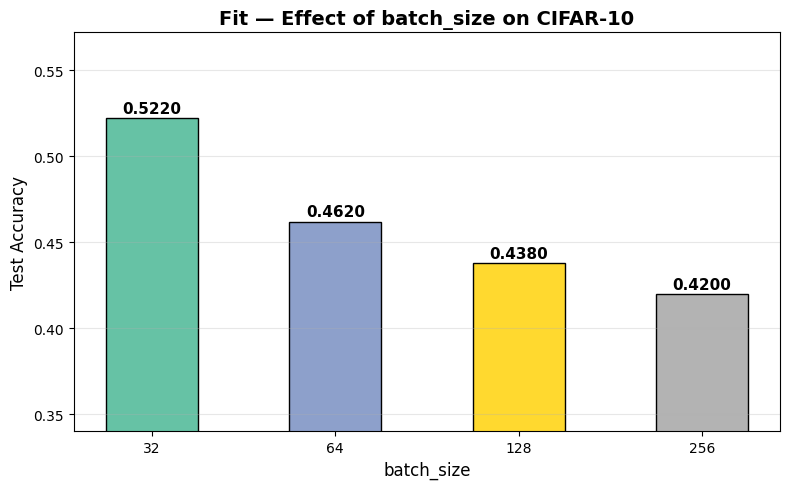

  Chart saved: assignment2_images/cnn_batch_size.png
--- 19.3 learning_rate ---
  Training: lr=0.0001 ... Accuracy = 0.3820
  Training: lr=0.001 ... Accuracy = 0.4540
  Training: lr=0.01 ... Accuracy = 0.3870


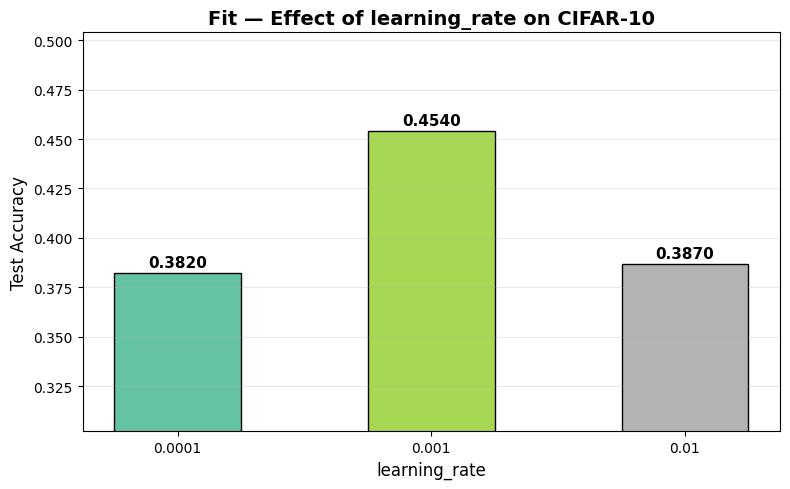

  Chart saved: assignment2_images/cnn_learning_rate.png
--- 19.4 validation_split ---
  Training: val_split=0.1 ... Accuracy = 0.4700
  Training: val_split=0.2 ... Accuracy = 0.4710
  Training: val_split=0.3 ... Accuracy = 0.5040


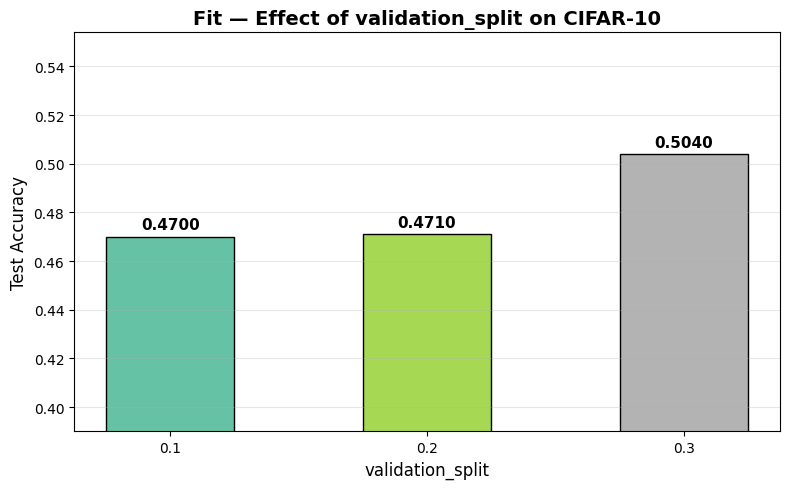

  Chart saved: assignment2_images/cnn_validation_split.png
--- 19.5 validation_data vs validation_split ---
  Training: validation_split=0.1 ... Accuracy = 0.5040
  Training: validation_data=(X,y) ... Accuracy = 0.4970


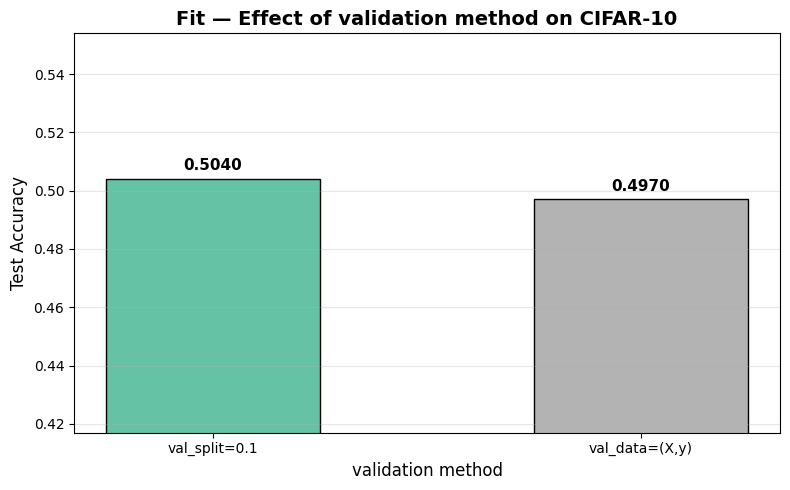

  Chart saved: assignment2_images/cnn_validation_method.png



In [234]:
# ============================================================
# 步骤 19：CNN 参数研究 — Fit 参数
# Step 19: CNN Parameter Study — Fit Parameters
# ============================================================
print("=" * LINE_WIDTH)
print("Step 19: CNN Parameter Study — Fit (5 parameters)")
print("=" * LINE_WIDTH)

# 21.1 epochs — 训练轮数
print("--- 19.1 epochs ---")
cnn_epoch_results = {}
for ep in [3, 5, 10, 15]:
    print(f"  Training: epochs={ep} ...", end=" ", flush=True)
    acc = train_keras_param(build_cnn_model, y_sub_train_oh, y_sub_test_oh,
                            f"cnn_epochs_{ep}", epochs=ep)
    cnn_epoch_results[str(ep)] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_epoch_results, 'epochs', 'cnn_epochs.png', 'Fit')

# 19.2 batch_size — 批大小
print("--- 19.2 batch_size ---")
cnn_bs_results = {}
for bs in [32, 64, 128, 256]:
    print(f"  Training: batch_size={bs} ...", end=" ", flush=True)
    acc = train_keras_param(build_cnn_model, y_sub_train_oh, y_sub_test_oh,
                            f"cnn_batch_{bs}", batch_size=bs)
    cnn_bs_results[str(bs)] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_bs_results, 'batch_size', 'cnn_batch_size.png', 'Fit')

# 19.3 learning_rate — 学习率
print("--- 19.3 learning_rate ---")
cnn_lr_results = {}
for lr in [0.0001, 0.001, 0.01]:
    print(f"  Training: lr={lr} ...", end=" ", flush=True)
    acc = train_keras_param(lambda l=lr: build_cnn_model(lr=l),
                            y_sub_train_oh, y_sub_test_oh, f"cnn_lr_{lr}")
    cnn_lr_results[str(lr)] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_lr_results, 'learning_rate', 'cnn_learning_rate.png', 'Fit')

# 19.4 validation_split — 验证集比例
print("--- 19.4 validation_split ---")
cnn_vs_results = {}
for vs in [0.1, 0.2, 0.3]:
    print(f"  Training: val_split={vs} ...", end=" ", flush=True)
    acc = train_keras_param(build_cnn_model, y_sub_train_oh, y_sub_test_oh,
                            f"cnn_valsplit_{vs}", validation_split=vs)
    cnn_vs_results[str(vs)] = acc
    print(f"Accuracy = {acc:.4f}")
plot_param_comparison(cnn_vs_results, 'validation_split', 'cnn_validation_split.png', 'Fit')

# 19.5 validation_data — 验证数据方式
# 19.5 validation_data vs validation_split
print("--- 19.5 validation_data vs validation_split ---")
cnn_valdata_results = {}

# Option 1: validation_split
print(f"  Training: validation_split=0.1 ...", end=" ", flush=True)
acc_split = train_keras_param(build_cnn_model, y_sub_train_oh, y_sub_test_oh,
                              "cnn_valmethod_split", validation_split=0.1)
cnn_valdata_results['val_split=0.1'] = acc_split
print(f"Accuracy = {acc_split:.4f}")

# Option 2: explicit validation_data
print(f"  Training: validation_data=(X,y) ...", end=" ", flush=True)
cache_file = CACHE_DIR / f'keras_param_cnn_valmethod_data_acc.pkl'
if cache_file.exists():
    with open(cache_file, 'rb') as f:
        acc_data = pickle.load(f)
else:
    m = build_cnn_model()
    split_idx = int(0.9 * len(X_sub_train))
    X_tr, X_val = X_sub_train[:split_idx], X_sub_train[split_idx:]
    y_tr, y_val = y_sub_train_oh[:split_idx], y_sub_train_oh[split_idx:]
    m.fit(X_tr, y_tr, epochs=5, batch_size=64,
          validation_data=(X_val, y_val), verbose=0)
    _, acc_data = m.evaluate(X_sub_test, y_sub_test_oh, verbose=0)
    with open(cache_file, 'wb') as f:
        pickle.dump(acc_data, f)
cnn_valdata_results['val_data=(X,y)'] = acc_data
print(f"Accuracy = {acc_data:.4f}")
plot_param_comparison(cnn_valdata_results, 'validation method', 'cnn_validation_method.png', 'Fit')
print()

cnn_all_params = [
    ('Conv2D: filters', cnn_filter_results),
    ('Conv2D: kernel_size', cnn_ks_results),
    ('Conv2D: strides', cnn_stride_results),
    ('Conv2D: padding', cnn_pad_results),
    ('Conv2D: activation', cnn_act_results),
    ('Conv2D: input_shape', cnn_input_results),
    ('Compile: optimizer', cnn_opt_results),
    ('Compile: loss', cnn_loss_results),
    ('Compile: metrics', cnn_metrics_results),
    ('Fit: epochs', cnn_epoch_results),
    ('Fit: batch_size', cnn_bs_results),
    ('Fit: learning_rate', cnn_lr_results),
    ('Fit: validation_split', cnn_vs_results),
    ('Fit: validation_data', cnn_valdata_results),
]

## Step 20: Parameter Study Summary

In [235]:
# ============================================================
# 步骤 20：参数研究总结
# Step 20: Parameter Study Summary
# ============================================================
print("=" * LINE_WIDTH)
print("Step 20: Parameter Study Summary")
print("=" * LINE_WIDTH)

# 主模型对比表
# Main model comparison table
print("\n=== Main Model Comparison ===\n")
conclusion_data = [
    ['MLP (sklearn)', f'{mlp_acc:.4f}', '50000', 'hidden=(256,128), relu, adam'],
    ['NN (Dense only)', f'{nn_acc:.4f}', '50000', 'Dense(512,256), relu, adam'],
    ['CNN Model 1', f'{cnn1_acc:.4f}', '50000', 'Conv+Dense (no pooling)'],
    ['CNN Model 2', f'{cnn2_acc:.4f}', '50000', 'Conv+MaxPool+Dense'],
    ['CNN Model 3', f'{cnn3_acc:.4f}', '50000', 'Conv+AvgPool+Dense'],
    ['CNN Model 4', f'{cnn4_acc:.4f}', '50000', 'Conv+MaxPool+AvgPool+Dense'],
]
print(tabulate(conclusion_data,
               headers=['Model', 'Accuracy', 'Train Size', 'Architecture'],
               tablefmt='grid'))

# 分模型参数研究汇总
# Per-model parameter study summary
all_param_groups = [
    ("MLP Parameters (sklearn)", mlp_all_params),
    ("Dense NN Parameters (Keras)", dense_all_params),
    ("CNN Parameters (Keras)", cnn_all_params),
]

for group_name, params in all_param_groups:
    print(f"\n=== {group_name} ===\n")
    summary_rows = []
    for param_name, results in params:
        best = max(results, key=results.get)
        worst = min(results, key=results.get)
        summary_rows.append([
            param_name,
            f"{best} ({results[best]:.4f})",
            f"{worst} ({results[worst]:.4f})",
        ])
    print(tabulate(summary_rows,
                   headers=['Parameter', 'Best (Accuracy)', 'Worst (Accuracy)'],
                   tablefmt='grid'))


total_param_models = sum(
    len(r) for _, params in all_param_groups for _, r in params)

print(f"""
{'='*LINE_WIDTH}
Assignment 2 Complete!
{'='*LINE_WIDTH}

Main models trained: 6 (MLP, NN, CNN1-4) on full 50000 samples
Parameter study models: {total_param_models} on {SUBSET_TRAIN} sample subset
Total models: {6 + total_param_models}
Total parameters studied: {sum(len(p) for _, p in all_param_groups)}
{'='*LINE_WIDTH}
""")

Step 20: Parameter Study Summary

=== Main Model Comparison ===

+-----------------+------------+--------------+------------------------------+
| Model           |   Accuracy |   Train Size | Architecture                 |
+=================+============+==============+==============================+
| MLP (sklearn)   |     0.5153 |        50000 | hidden=(256,128), relu, adam |
+-----------------+------------+--------------+------------------------------+
| NN (Dense only) |     0.4103 |        50000 | Dense(512,256), relu, adam   |
+-----------------+------------+--------------+------------------------------+
| CNN Model 1     |     0.6235 |        50000 | Conv+Dense (no pooling)      |
+-----------------+------------+--------------+------------------------------+
| CNN Model 2     |     0.7212 |        50000 | Conv+MaxPool+Dense           |
+-----------------+------------+--------------+------------------------------+
| CNN Model 3     |     0.7024 |        50000 | Conv+AvgPool+Dense